<a href="https://colab.research.google.com/github/JPAmewu/My_Capstone_1_Imperial/blob/main/Week_12_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12 Capstone — Bayesian Optimisation

This notebook appends the confirmed Week 11 observations to the Week 11 dataset, creating the Week 12 dataset before EDA and GP/UCB query selection.


For each function for Week_11, I will follow this sequence:
1. Create week_12_dataset
2. Extract function
3. Check shapes and missing values
4. Calculate summary statistics
5. Plot the output trend
6. Plot the best-so-far trend
7. Identify the best query point
8. Plot the correlation heatmap
9. Plot each input against the output
10. Fit a Gaussian Process surrogate
11. Apply UCB to generate the next query point

In [43]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn

In [44]:
# 1. Unzip the Week 11 dataset

import os
import shutil
import zipfile

import numpy as np

zip_path = "/content/week_11_dataset.zip"
extract_path = "/content/week_11_dataset"

# Remove an old extracted copy, if present.
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Week 11 dataset extracted successfully.")


Week 11 dataset extracted successfully.


In [45]:
# 2. Check the extracted .npy files

for root, folders, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".npy"):
            print(os.path.join(root, file))

/content/week_11_dataset/week_11_dataset/function_6_outputs.npy
/content/week_11_dataset/week_11_dataset/function_5_outputs.npy
/content/week_11_dataset/week_11_dataset/function_7_outputs.npy
/content/week_11_dataset/week_11_dataset/function_8_outputs.npy
/content/week_11_dataset/week_11_dataset/function_2_outputs.npy
/content/week_11_dataset/week_11_dataset/function_6_inputs.npy
/content/week_11_dataset/week_11_dataset/function_1_outputs.npy
/content/week_11_dataset/week_11_dataset/function_2_inputs.npy
/content/week_11_dataset/week_11_dataset/function_4_outputs.npy
/content/week_11_dataset/week_11_dataset/function_7_inputs.npy
/content/week_11_dataset/week_11_dataset/function_5_inputs.npy
/content/week_11_dataset/week_11_dataset/function_1_inputs.npy
/content/week_11_dataset/week_11_dataset/function_3_inputs.npy
/content/week_11_dataset/week_11_dataset/function_4_inputs.npy
/content/week_11_dataset/week_11_dataset/function_3_outputs.npy
/content/week_11_dataset/week_11_dataset/functi

In [46]:
import os

for root, dirs, files in os.walk("/content/week_11_dataset"):
    print("FOLDER:", root)
    for file in files:
        if file.endswith(".npy"):
            print("   ", file)

FOLDER: /content/week_11_dataset
FOLDER: /content/week_11_dataset/week_11_dataset
    function_6_outputs.npy
    function_5_outputs.npy
    function_7_outputs.npy
    function_8_outputs.npy
    function_2_outputs.npy
    function_6_inputs.npy
    function_1_outputs.npy
    function_2_inputs.npy
    function_4_outputs.npy
    function_7_inputs.npy
    function_5_inputs.npy
    function_1_inputs.npy
    function_3_inputs.npy
    function_4_inputs.npy
    function_3_outputs.npy
    function_8_inputs.npy


In [47]:
# 3. Load and validate the Week 11 dataset

EXPECTED_DIMENSIONS = {
    1: 2,
    2: 2,
    3: 3,
    4: 4,
    5: 4,
    6: 5,
    7: 6,
    8: 8,
}


def find_npy_file(folder, function_number, data_type):
    """Return the unique input or output array for a function."""
    if data_type not in {"input", "output"}:
        raise ValueError("data_type must be 'input' or 'output'.")

    expected_name = f"function_{function_number}_{data_type}s.npy"
    matching_files = sorted(
        os.path.join(root, filename)
        for root, _, files in os.walk(folder)
        for filename in files
        if filename.lower() == expected_name
    )

    if not matching_files:
        raise FileNotFoundError(
            f"No exact {data_type} file found for Function "
            f"{function_number}: {expected_name}"
        )

    if len(matching_files) > 1:
        raise RuntimeError(
            f"Multiple {data_type} files found for Function "
            f"{function_number}: {matching_files}"
        )

    return matching_files[0]


week_10_X = {}
week_10_y = {}

for function_number in range(1, 9):
    input_file = find_npy_file(
        extract_path,
        function_number,
        "input",
    )
    output_file = find_npy_file(
        extract_path,
        function_number,
        "output",
    )

    expected_dimension = EXPECTED_DIMENSIONS[function_number]
    inputs = np.asarray(np.load(input_file), dtype=float)
    outputs = np.asarray(np.load(output_file), dtype=float).reshape(-1, 1)

    if inputs.ndim == 1:
        if inputs.size % expected_dimension:
            raise ValueError(
                f"Function {function_number}: {inputs.size} input values "
                f"cannot be reshaped to dimension {expected_dimension}."
            )
        inputs = inputs.reshape(-1, expected_dimension)

    if inputs.ndim != 2 or inputs.shape[1] != expected_dimension:
        raise ValueError(
            f"Function {function_number}: expected a two-dimensional input "
            f"array with {expected_dimension} columns, got {inputs.shape}."
        )

    if not np.isfinite(inputs).all() or not np.isfinite(outputs).all():
        raise ValueError(
            f"Function {function_number}: input or output contains "
            "non-finite values."
        )

    week_10_X[function_number] = inputs
    week_10_y[function_number] = outputs

    print(f"Function {function_number}")
    print("Input shape :", inputs.shape)
    print("Output shape:", outputs.shape)
    print("-" * 40)


Function 1
Input shape : (21, 2)
Output shape: (21, 1)
----------------------------------------
Function 2
Input shape : (21, 2)
Output shape: (21, 1)
----------------------------------------
Function 3
Input shape : (26, 3)
Output shape: (26, 1)
----------------------------------------
Function 4
Input shape : (41, 4)
Output shape: (41, 1)
----------------------------------------
Function 5
Input shape : (31, 4)
Output shape: (31, 1)
----------------------------------------
Function 6
Input shape : (31, 5)
Output shape: (31, 1)
----------------------------------------
Function 7
Input shape : (41, 6)
Output shape: (41, 1)
----------------------------------------
Function 8
Input shape : (50, 8)
Output shape: (50, 1)
----------------------------------------


In [48]:

# Validate Week 11 input-output alignment

for function_number in range(1, 9):

    input_file = find_npy_file(
        extract_path,
        function_number,
        "input"
    )

    output_file = find_npy_file(
        extract_path,
        function_number,
        "output"
    )

    inputs = np.load(input_file)
    outputs = np.load(output_file)

    print(
        f"Function {function_number}: "
        f"inputs {inputs.shape}, outputs {outputs.shape}"
    )

    if inputs.shape[0] != outputs.shape[0]:
        raise ValueError(
            f"Function {function_number}: "
            f"{inputs.shape[0]} inputs but {outputs.shape[0]} outputs"
        )

print("\nAll Week 11 input and output arrays are aligned.")


Function 1: inputs (21, 2), outputs (21, 1)
Function 2: inputs (21, 2), outputs (21, 1)
Function 3: inputs (26, 3), outputs (26, 1)
Function 4: inputs (41, 4), outputs (41, 1)
Function 5: inputs (31, 4), outputs (31, 1)
Function 6: inputs (31, 5), outputs (31, 1)
Function 7: inputs (41, 6), outputs (41, 1)
Function 8: inputs (50, 8), outputs (50, 1)

All Week 11 input and output arrays are aligned.


In [49]:
# Raw Week 11 files remain unchanged.

print("Validation complete; no source dataset files were overwritten.")

Validation complete; no source dataset files were overwritten.


In [50]:
import ast
import numpy as np

# Read the text files
with open('/content/week_11_inputs.txt', 'r') as f:
    inputs_text = f.read()

with open('/content/week_11_outputs.txt', 'r') as f:
    outputs_text = f.read()

print("INPUT FILE:")
print(inputs_text[:1000])

print("\nOUTPUT FILE:")
print(outputs_text[:1000])

INPUT FILE:
[array([0.37454 , 0.950714]), array([0.37454 , 0.950714]), array([0.444444, 0.666666, 0.333333]), array([0.555555, 0.444444, 0.222222, 0.111111]), array([0.224189, 0.84648 , 0.879484, 0.878515]), array([0.728186, 0.154693, 0.732552, 0.693997, 0.564013]), array([0.045091, 0.528666, 0.329265, 0.10535 , 0.434667, 0.641164]), array([0.273673, 0.2604  , 0.073937, 0.078562, 0.862321, 0.230729,
       0.108688, 0.352588])]
[array([0.536429, 0.835362]), array([0.978752, 0.932731]), array([0.657452, 0.998464, 0.817253]), array([0.00628 , 0.28184 , 0.932013, 0.960202]), array([0.255841, 0.841692, 0.888984, 0.86026 ]), array([0.433654, 0.486678, 0.282753, 0.972905, 0.323321]), array([0.243848, 0.9001  , 0.696978, 0.19363 , 0.374149, 0.826324]), array([0.16316 , 0.184786, 0.152644, 0.083802, 0.999322, 0.544113,
       0.184124, 0.123846])]
[array([0.614168, 0.334143]), array([6.00000e-06, 3.34143e-01]), array([0.670026, 0.057881, 0.658241]), array([0.394519, 0.361122, 0.256803, 0.46185

In [51]:
import re
import numpy as np

# Read files
with open('/content/week_11_inputs.txt', 'r') as f:
    inputs_text = f.read()

with open('/content/week_11_outputs.txt', 'r') as f:
    outputs_text = f.read()

# Extract every array(...) from the input file
array_strings = re.findall(r'array\(\[([^\]]+)\]\)', inputs_text)

input_arrays = [
    np.array([float(x.strip()) for x in s.split(',')])
    for s in array_strings
]

# Extract np.float64(...) values from output file
output_values = [
    float(x)
    for x in re.findall(r'np\.float64\(([^)]+)\)', outputs_text)
]

print("Number of input arrays:", len(input_arrays))
print("Number of outputs:", len(output_values))

print("\nLAST 8 INPUT ARRAYS:")
for x in input_arrays[-8:]:
    print(x)

print("\nLAST 8 OUTPUT VALUES:")
for y in output_values[-8:]:
    print(y)

Number of input arrays: 88
Number of outputs: 32

LAST 8 INPUT ARRAYS:
[0.353293 0.956697]
[0.384537 0.996119]
[0.450034 0.667941 0.342989]
[0.80766  0.348421 0.277162 0.044827]
[0.016444 0.027486 0.656999 0.955172]
[0.67859  0.144728 0.730278 0.715653 0.604728]
[0.280913 0.512275 0.321637 0.188234 0.420546 0.641027]
[0.234325 0.196964 0.387716 0.46245  0.845967 0.154645 0.549698 0.111557]

LAST 8 OUTPUT VALUES:
-2.4666412561217706e-107
0.038774938576018964
-0.08251349582236739
-9.312811809021998
163.1225
-2.4375082517089726
1.2087334449610816
9.2540644925525


In [52]:
import re
import numpy as np

# ---------- INPUTS ----------
with open('/content/week_11_inputs.txt', 'r') as f:
    inputs_text = f.read()

array_strings = re.findall(
    r'array\(\[([^\]]+)\]\)',
    inputs_text
)

input_arrays = [
    np.array([float(v.strip()) for v in s.split(',')])
    for s in array_strings
]


# ---------- OUTPUTS ----------
with open('/content/week_11_outputs.txt', 'r') as f:
    outputs_text = f.read()

# Remove numpy wrappers such as np.float64(...)
clean_outputs = re.sub(
    r'np\.float64\(([^)]+)\)',
    r'\1',
    outputs_text
)

# Extract all numeric values
output_values = [
    float(x)
    for x in re.findall(
        r'[-+]?(?:\d*\.\d+|\d+\.?)(?:[eE][-+]?\d+)?',
        clean_outputs
    )
]


print("Number of input arrays:", len(input_arrays))
print("Number of outputs:", len(output_values))

print("\nLAST 8 INPUTS:")
for i, x in enumerate(input_arrays[-8:], start=1):
    print(f"Function {i}: {x}")

print("\nLAST 8 OUTPUTS:")
for i, y in enumerate(output_values[-8:], start=1):
    print(f"Function {i}: {y}")

Number of input arrays: 88
Number of outputs: 88

LAST 8 INPUTS:
Function 1: [0.353293 0.956697]
Function 2: [0.384537 0.996119]
Function 3: [0.450034 0.667941 0.342989]
Function 4: [0.80766  0.348421 0.277162 0.044827]
Function 5: [0.016444 0.027486 0.656999 0.955172]
Function 6: [0.67859  0.144728 0.730278 0.715653 0.604728]
Function 7: [0.280913 0.512275 0.321637 0.188234 0.420546 0.641027]
Function 8: [0.234325 0.196964 0.387716 0.46245  0.845967 0.154645 0.549698 0.111557]

LAST 8 OUTPUTS:
Function 1: 8.159220183163013e-130
Function 2: 0.06529972619341909
Function 3: -0.038446126253640946
Function 4: -14.992666345077428
Function 5: 210.03831315192616
Function 6: -1.154424131709899
Function 7: 1.478174096441659
Function 8: 9.2760687615836


In [53]:
# Take the latest 8 Week 11 input/output pairs

new_X = {
    i + 1: input_arrays[-8 + i].reshape(1, -1)
    for i in range(8)
}

new_y = {
    i + 1: np.array([[output_values[-8 + i]]], dtype=float)
    for i in range(8)
}

# Verify
for function_number in range(1, 9):
    print(f"\nFunction {function_number}")
    print("Input :", new_X[function_number])
    print("Output:", new_y[function_number])
    print(
        "Shapes:",
        new_X[function_number].shape,
        new_y[function_number].shape
    )


Function 1
Input : [[0.353293 0.956697]]
Output: [[8.15922018e-130]]
Shapes: (1, 2) (1, 1)

Function 2
Input : [[0.384537 0.996119]]
Output: [[0.06529973]]
Shapes: (1, 2) (1, 1)

Function 3
Input : [[0.450034 0.667941 0.342989]]
Output: [[-0.03844613]]
Shapes: (1, 3) (1, 1)

Function 4
Input : [[0.80766  0.348421 0.277162 0.044827]]
Output: [[-14.99266635]]
Shapes: (1, 4) (1, 1)

Function 5
Input : [[0.016444 0.027486 0.656999 0.955172]]
Output: [[210.03831315]]
Shapes: (1, 4) (1, 1)

Function 6
Input : [[0.67859  0.144728 0.730278 0.715653 0.604728]]
Output: [[-1.15442413]]
Shapes: (1, 5) (1, 1)

Function 7
Input : [[0.280913 0.512275 0.321637 0.188234 0.420546 0.641027]]
Output: [[1.4781741]]
Shapes: (1, 6) (1, 1)

Function 8
Input : [[0.234325 0.196964 0.387716 0.46245  0.845967 0.154645 0.549698 0.111557]]
Output: [[9.27606876]]
Shapes: (1, 8) (1, 1)


In [54]:
print("TYPE OF inputs:", type(inputs))
print("TYPE OF outputs:", type(outputs))

print("\nINPUT SHAPES:")
for i in range(1, 9):
    try:
        print(f"Function {i}: {np.asarray(inputs[i]).shape}")
    except Exception as e:
        print(f"Function {i}: ERROR - {e}")

print("\nOUTPUT SHAPES:")
for i in range(1, 9):
    try:
        print(f"Function {i}: {np.asarray(outputs[i]).shape}")
    except Exception as e:
        print(f"Function {i}: ERROR - {e}")

TYPE OF inputs: <class 'numpy.ndarray'>
TYPE OF outputs: <class 'numpy.ndarray'>

INPUT SHAPES:
Function 1: (8,)
Function 2: (8,)
Function 3: (8,)
Function 4: (8,)
Function 5: (8,)
Function 6: (8,)
Function 7: (8,)
Function 8: (8,)

OUTPUT SHAPES:
Function 1: (1,)
Function 2: (1,)
Function 3: (1,)
Function 4: (1,)
Function 5: (1,)
Function 6: (1,)
Function 7: (1,)
Function 8: (1,)


In [55]:
import numpy as np
import glob
import os

week_11_X = {}
week_11_y = {}

for f in range(1, 9):

    input_file = glob.glob(
        f"/content/week_11_dataset/**/function_{f}_inputs.npy",
        recursive=True
    )[0]

    output_file = glob.glob(
        f"/content/week_11_dataset/**/function_{f}_outputs.npy",
        recursive=True
    )[0]

    week_11_X[f] = np.load(input_file)
    week_11_y[f] = np.load(output_file)

    # Make sure outputs are 2-dimensional
    week_11_y[f] = week_11_y[f].reshape(-1, 1)

    print(
        f"Function {f}: "
        f"inputs {week_11_X[f].shape}, "
        f"outputs {week_11_y[f].shape}"
    )

Function 1: inputs (21, 2), outputs (21, 1)
Function 2: inputs (21, 2), outputs (21, 1)
Function 3: inputs (26, 3), outputs (26, 1)
Function 4: inputs (41, 4), outputs (41, 1)
Function 5: inputs (31, 4), outputs (31, 1)
Function 6: inputs (31, 5), outputs (31, 1)
Function 7: inputs (41, 6), outputs (41, 1)
Function 8: inputs (50, 8), outputs (50, 1)


In [56]:
# Create Week 12 dataset by appending the new Week 11 query results
# to the complete Week 11 dataset

week_12_X = {}
week_12_y = {}

for function_number in range(1, 9):

    # Load the complete Week 11 dataset
    input_file = find_npy_file(
        extract_path,
        function_number,
        "input"
    )

    output_file = find_npy_file(
        extract_path,
        function_number,
        "output"
    )

    week_11_inputs = np.load(input_file)
    week_11_outputs = np.load(output_file)

    # Make sure output arrays are 1-dimensional
    week_11_outputs = np.asarray(
        week_11_outputs
    ).reshape(-1)

    new_output = np.asarray(
        new_y[function_number]
    ).reshape(-1)

    # Append Week 11's new query/result
    week_12_X[function_number] = np.vstack([
        week_11_inputs,
        new_X[function_number]
    ])

    week_12_y[function_number] = np.concatenate([
        week_11_outputs,
        new_output
    ])

    print(
        f"Function {function_number}: "
        f"Week 12 input {week_12_X[function_number].shape}, "
        f"output {week_12_y[function_number].shape}"
    )

Function 1: Week 12 input (22, 2), output (22,)
Function 2: Week 12 input (22, 2), output (22,)
Function 3: Week 12 input (27, 3), output (27,)
Function 4: Week 12 input (42, 4), output (42,)
Function 5: Week 12 input (32, 4), output (32,)
Function 6: Week 12 input (32, 5), output (32,)
Function 7: Week 12 input (42, 6), output (42,)
Function 8: Week 12 input (51, 8), output (51,)


In [57]:
from google.colab import drive

drive.mount("/content/drive")

week_12_folder = "/content/drive/MyDrive/week_12_dataset"
os.makedirs(week_12_folder, exist_ok=True)

for function_number in range(1, 9):
    input_file = os.path.join(
        week_12_folder,
        f"function_{function_number}_inputs.npy",
    )
    output_file = os.path.join(
        week_12_folder,
        f"function_{function_number}_outputs.npy",
    )

    np.save(input_file, week_12_X[function_number])
    np.save(output_file, week_12_y[function_number])

print("Week 12 dataset saved successfully.")
print("Folder:", week_12_folder)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Week 12 dataset saved successfully.
Folder: /content/drive/MyDrive/week_12_dataset


In [58]:
for function_number in range(1, 9):

    saved_X = np.load(
        os.path.join(
            week_12_folder,
            f"function_{function_number}_inputs.npy"
        )
    )

    saved_y = np.load(
        os.path.join(
            week_12_folder,
            f"function_{function_number}_outputs.npy"
        )
    )

    status = (
        "MATCHED"
        if saved_X.shape[0] == saved_y.shape[0]
        else "NOT MATCHED"
    )

    print(
        f"Function {function_number}: "
        f"input {saved_X.shape}, "
        f"output {saved_y.shape} — {status}"
    )

Function 1: input (22, 2), output (22,) — MATCHED
Function 2: input (22, 2), output (22,) — MATCHED
Function 3: input (27, 3), output (27,) — MATCHED
Function 4: input (42, 4), output (42,) — MATCHED
Function 5: input (32, 4), output (32,) — MATCHED
Function 6: input (32, 5), output (32,) — MATCHED
Function 7: input (42, 6), output (42,) — MATCHED
Function 8: input (51, 8), output (51,) — MATCHED


In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")




**Function**-by-function EDA function

1. Loading of inputs and outputs
2. Shape checks
3. Missing and infinite-value checks
4. Summary statistics
5. Output trend
6. Best-so-far trend
7. Best observed query point
8. Correlation heatmap
9. Input-output scatter plots
10. Top five observations

In [60]:
def conduct_function_eda(function_number, dataset_folder):
    """
    Conduct exploratory data analysis for one black-box function.

    Parameters
    ----------
    function_number : int
        Function number from 1 to 8.

    dataset_folder : str
        Folder containing the .npy files.
    """

    # ---------------------------------------------------------
    # 1. Build the file paths
    # ---------------------------------------------------------
    input_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_inputs.npy"
    )

    output_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_outputs.npy"
    )

    # ---------------------------------------------------------
    # 2. Check that the files exist
    # ---------------------------------------------------------
    if not os.path.exists(input_path):
        raise FileNotFoundError(
            f"Input file not found: {input_path}"
        )

    if not os.path.exists(output_path):
        raise FileNotFoundError(
            f"Output file not found: {output_path}"
        )

    # ---------------------------------------------------------
    # 3. Load the arrays
    # ---------------------------------------------------------
    X = np.load(input_path)
    y = np.load(output_path)

    # Make sure X is two-dimensional
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # Convert output from shape (n, 1) into shape (n,)
    y = y.reshape(-1)

    # ---------------------------------------------------------
    # 4. Check input-output matching
    # ---------------------------------------------------------
    if X.shape[0] != y.shape[0]:
        raise ValueError(
            f"Function {function_number} is not matched: "
            f"{X.shape[0]} input rows and {y.shape[0]} outputs."
        )

    # ---------------------------------------------------------
    # 5. Create a DataFrame
    # ---------------------------------------------------------
    input_columns = [
        f"x{i + 1}" for i in range(X.shape[1])
    ]

    df = pd.DataFrame(
        X,
        columns=input_columns
    )

    df["output"] = y

    # ---------------------------------------------------------
    # 6. Basic information
    # ---------------------------------------------------------
    print("\n")
    print("=" * 70)
    print(f"FUNCTION {function_number} EDA")
    print("=" * 70)

    print("\nDataset structure")
    print("-" * 40)
    print("Input shape :", X.shape)
    print("Output shape:", y.shape)
    print("Observations:", X.shape[0])
    print("Dimensions  :", X.shape[1])

    print("\nFirst five observations")
    print("-" * 40)
    display(df.head())

    # ---------------------------------------------------------
    # 7. Data-quality checks
    # ---------------------------------------------------------
    missing_values = df.isnull().sum()
    infinite_values = pd.Series(
        np.isinf(df.to_numpy()).sum(axis=0),
        index=df.columns
    )

    duplicate_rows = df.duplicated().sum()

    print("\nMissing values")
    print("-" * 40)
    print(missing_values)

    print("\nInfinite values")
    print("-" * 40)
    print(infinite_values)

    print("\nDuplicate rows")
    print("-" * 40)
    print(duplicate_rows)

    # ---------------------------------------------------------
    # 8. Summary statistics
    # ---------------------------------------------------------
    summary = df.describe().T

    summary["median"] = df.median()
    summary["variance"] = df.var()
    summary["skewness"] = df.skew()

    print("\nSummary statistics")
    print("-" * 40)
    display(summary)

    # ---------------------------------------------------------
    # 9. Find the best observed result
    # Maximisation objective
    # ---------------------------------------------------------
    best_index = int(np.argmax(y))
    best_output = float(y[best_index])
    best_input = X[best_index]

    print("\nBest observed result")
    print("-" * 40)
    print("Best array index       :", best_index)
    print("Best observation number:", best_index + 1)
    print("Best query point       :", best_input)
    print("Best output value      :", best_output)

    # ---------------------------------------------------------
    # 10. Top five observations
    # ---------------------------------------------------------
    top_five = (
        df.sort_values(
            by="output",
            ascending=False
        )
        .head(5)
    )

    print("\nTop five observations")
    print("-" * 40)
    display(top_five)

    # ---------------------------------------------------------
    # 11. Output trend
    # ---------------------------------------------------------
    observation_numbers = np.arange(1, len(y) + 1)

    plt.figure(figsize=(11, 5))

    plt.plot(
        observation_numbers,
        y,
        marker="o"
    )

    plt.scatter(
        best_index + 1,
        best_output,
        marker="*",
        s=250,
        label="Best observed output"
    )

    plt.xlabel("Observation number")
    plt.ylabel("Output")
    plt.title(
        f"Function {function_number}: Output Trend"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 12. Best-so-far trend
    # ---------------------------------------------------------
    best_so_far = np.maximum.accumulate(y)

    plt.figure(figsize=(11, 5))

    plt.plot(
        observation_numbers,
        best_so_far,
        marker="o"
    )

    plt.xlabel("Observation number")
    plt.ylabel("Best output found so far")
    plt.title(
        f"Function {function_number}: Best-So-Far Trend"
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 13. Output distribution
    # ---------------------------------------------------------
    plt.figure(figsize=(9, 5))

    plt.hist(
        y,
        bins= 8,
        edgecolor="black"
    )

    plt.axvline(
        np.mean(y),
        linestyle="--",
        label=f"Mean = {np.mean(y):.5g}"
    )

    plt.axvline(
        np.median(y),
        linestyle=":",
        label=f"Median = {np.median(y):.5g}"
    )

    plt.xlabel("Output")
    plt.ylabel("Frequency")
    plt.title(
        f"Function {function_number}: Output Distribution"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 14. Correlation heatmap
    # ---------------------------------------------------------
    correlation = df.corr(numeric_only=True)

    plt.figure(
        figsize=(
            max(7, X.shape[1] + 3),
            max(5, X.shape[1] + 2)
        )
    )

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title(
        f"Function {function_number}: Correlation Heatmap"
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 15. Each input against the output
    # ---------------------------------------------------------
    for column in input_columns:

        plt.figure(figsize=(8, 5))

        plt.scatter(
            df[column],
            df["output"],
            alpha=0.75
        )

        plt.scatter(
            df.loc[best_index, column],
            df.loc[best_index, "output"],
            marker="*",
            s=250,
            label="Best observed point"
        )

        plt.xlabel(column)
        plt.ylabel("Output")

        plt.title(
            f"Function {function_number}: "
            f"{column} Against Output"
        )

        plt.legend()
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------
    # 16. Input-output correlations
    # ---------------------------------------------------------
    output_correlations = (
        correlation["output"]
        .drop("output")
        .sort_values(
            key=lambda values: values.abs(),
            ascending=False
        )
    )

    print("\nInput-output correlations")
    print("-" * 40)
    print(output_correlations)

    # ---------------------------------------------------------
    # 17. Concise report
    # ---------------------------------------------------------
    print("\nConcise EDA report")
    print("-" * 40)

    print(f"Observations       : {X.shape[0]}")
    print(f"Input dimensions   : {X.shape[1]}")
    print(f"Missing values     : {df.isnull().sum().sum()}")
    print(f"Infinite values    : {np.isinf(df.to_numpy()).sum()}")
    print(f"Duplicate rows     : {duplicate_rows}")
    print(f"Minimum output     : {np.min(y):.10g}")
    print(f"Mean output        : {np.mean(y):.10g}")
    print(f"Median output      : {np.median(y):.10g}")
    print(f"Maximum output     : {np.max(y):.10g}")
    print(f"Best observation   : {best_index + 1}")
    print(f"Best query point   : {best_input}")
    print(f"Best output        : {best_output:.10g}")

    # Return the important objects
    return {
        "function": function_number,
        "X": X,
        "y": y,
        "dataframe": df,
        "summary": summary,
        "correlation": correlation,
        "best_index": best_index,
        "best_input": best_input,
        "best_output": best_output,
        "best_so_far": best_so_far,
        "top_five": top_five
    }



FUNCTION 1 EDA

Dataset structure
----------------------------------------
Input shape : (22, 2)
Output shape: (22,)
Observations: 22
Dimensions  : 2

First five observations
----------------------------------------


,x1,x2,output
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03



Missing values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,22.0,0.501828,0.229123,0.082507,3.745400e-01,3.794030e-01,6.750921e-01,0.897714,3.794030e-01,0.052497,0.573721
x2,22.0,0.606663,0.373871,0.071186,1.768486e-01,7.479796e-01,9.507140e-01,0.999543,7.479796e-01,0.139780,-0.503956
output,22.0,11.636200,25.265424,-0.003606,-2.317068e-96,1.670890e-124,1.901251e-40,64.000000,1.670890e-124,638.341659,1.773180



Best observed result
----------------------------------------
Best array index       : 10
Best observation number: 11
Best query point       : [0.37454  0.950714]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,output
12,0.374540,0.950714,6.400000e+01
13,0.374540,0.950714,6.400000e+01
10,0.374540,0.950714,6.400000e+01
11,0.374540,0.950714,6.400000e+01
2,0.731024,0.733000,7.710875e-16


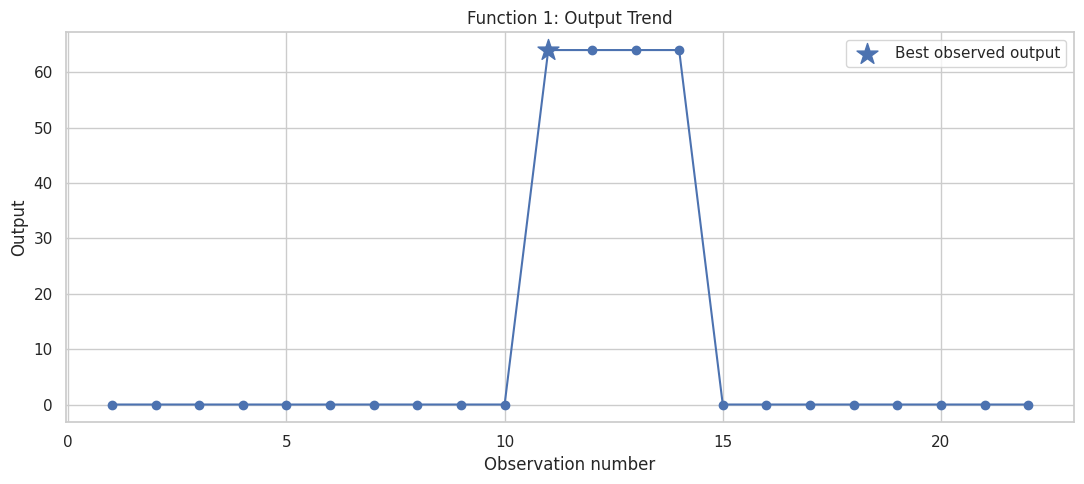

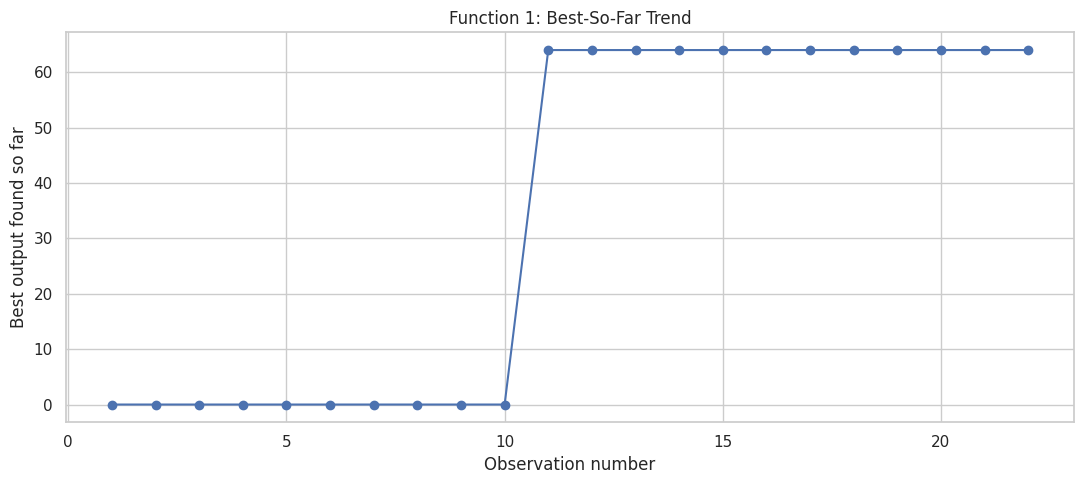

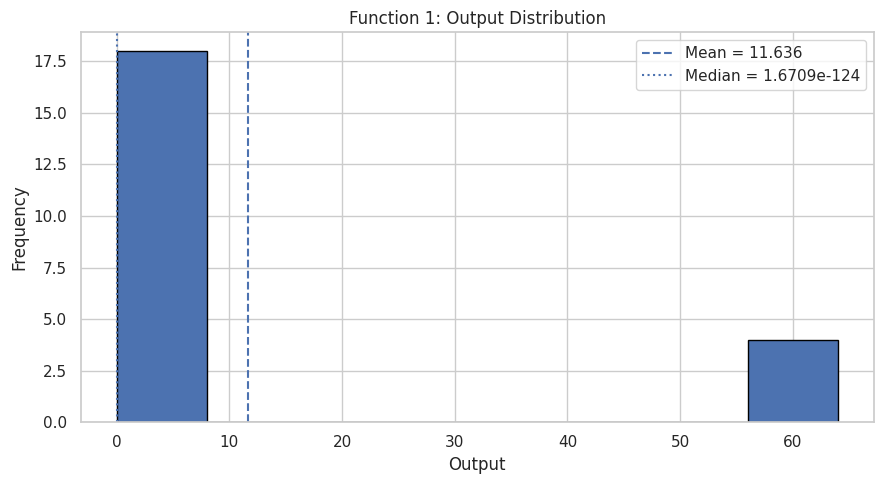

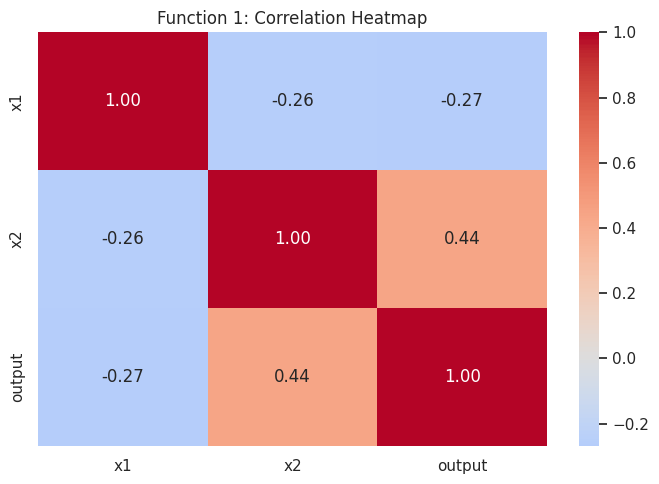

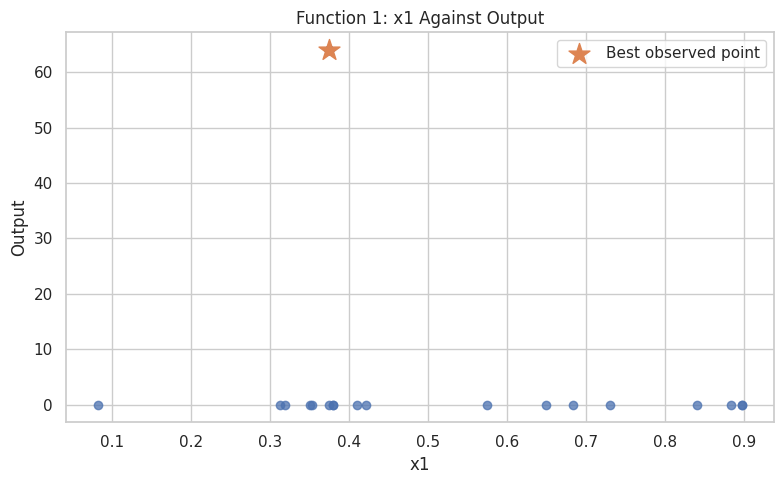

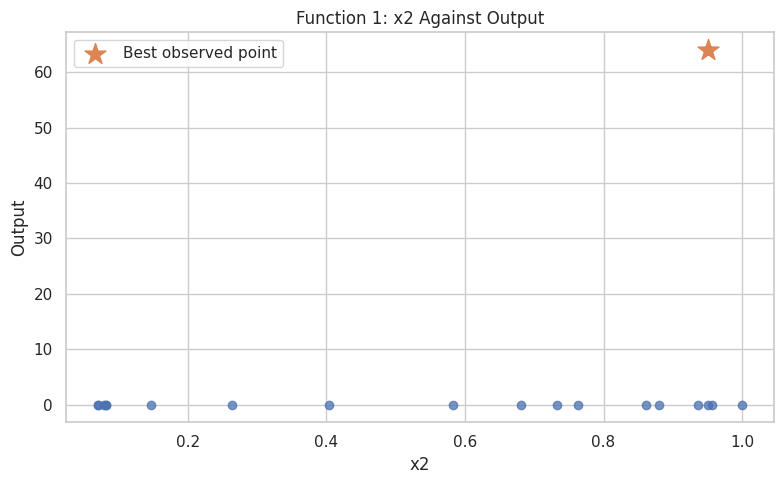


Input-output correlations
----------------------------------------
x2    0.444011
x1   -0.268053
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 22
Input dimensions   : 2
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : -0.003606062644
Mean output        : 11.63619972
Median output      : 1.670889583e-124
Maximum output     : 64
Best observation   : 11
Best query point   : [0.37454  0.950714]
Best output        : 64


In [77]:
# Conduct Function 1 EDA


eda_1 = conduct_function_eda(
    function_number=1,
    dataset_folder=week_12_folder
)



FUNCTION 2 EDA

Dataset structure
----------------------------------------
Input shape : (22, 2)
Output shape: (22,)
Observations: 22
Dimensions  : 2

First five observations
----------------------------------------


,x1,x2,output
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965



Missing values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,22.0,0.473469,0.233812,0.009675,0.349947,0.379539,0.572118,0.995366,0.379539,0.054668,0.527535
x2,22.0,0.656789,0.351038,0.028698,0.351987,0.775300,0.950714,0.999881,0.775300,0.123228,-0.577778
output,22.0,3.044486,13.615881,-0.065624,0.005776,0.049406,0.238660,64.000000,0.049406,185.392224,4.688968



Best observed result
----------------------------------------
Best array index       : 13
Best observation number: 14
Best query point       : [0.37454  0.950714]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,output
13,0.374540,0.950714,64.000000
9,0.702637,0.926564,0.611205
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
3,0.845275,0.711120,0.293993


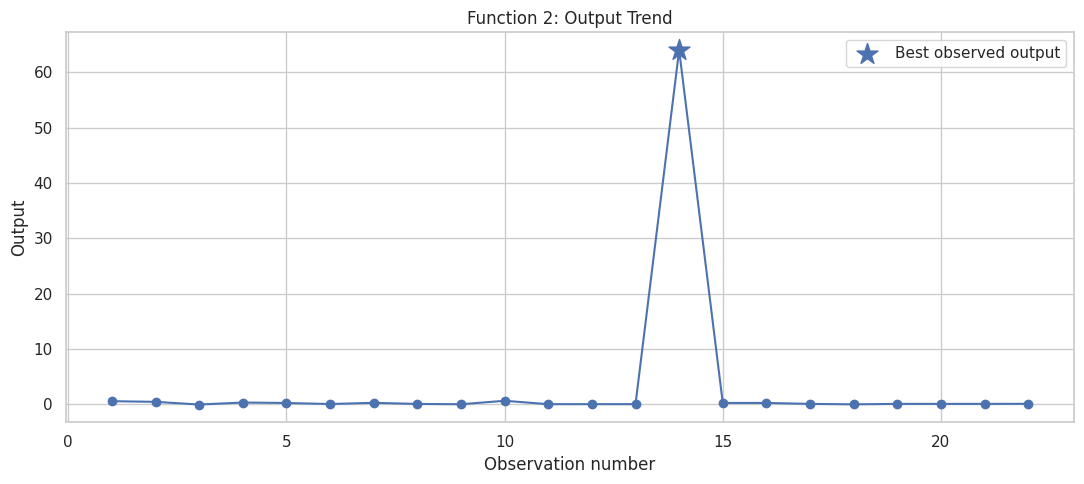

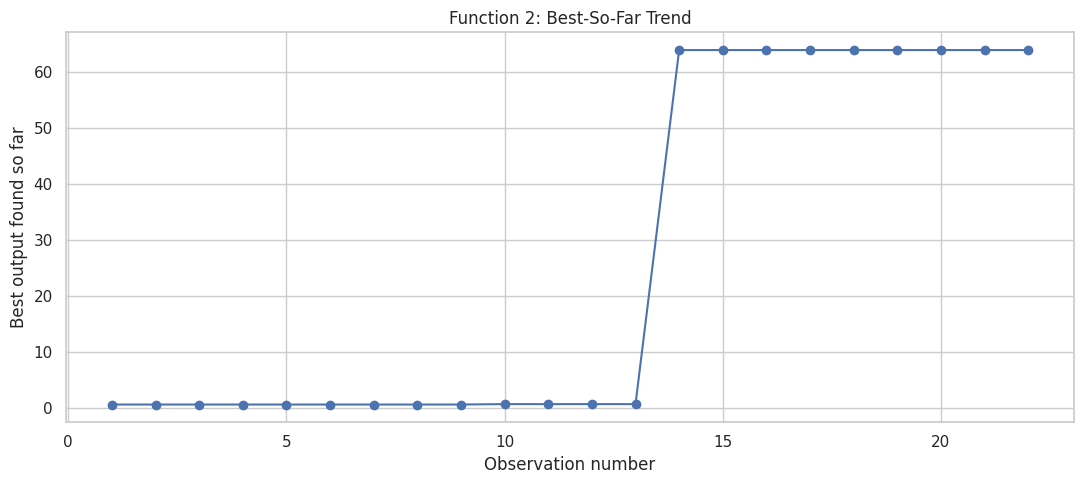

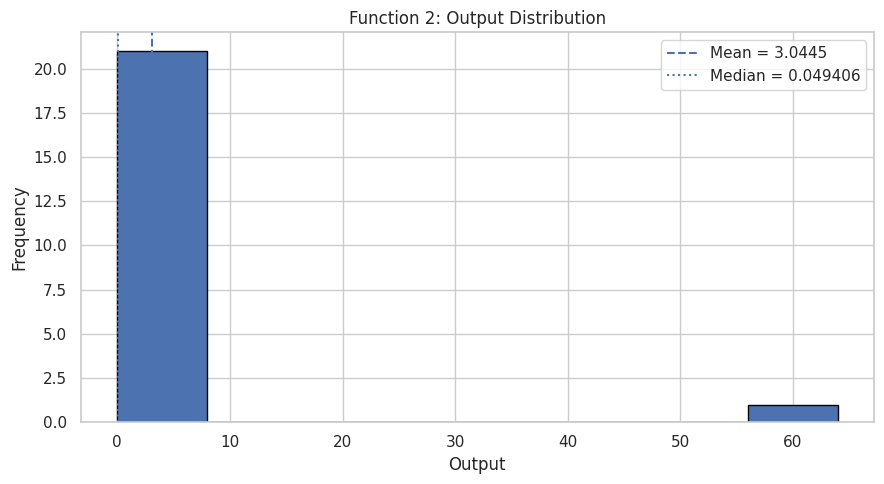

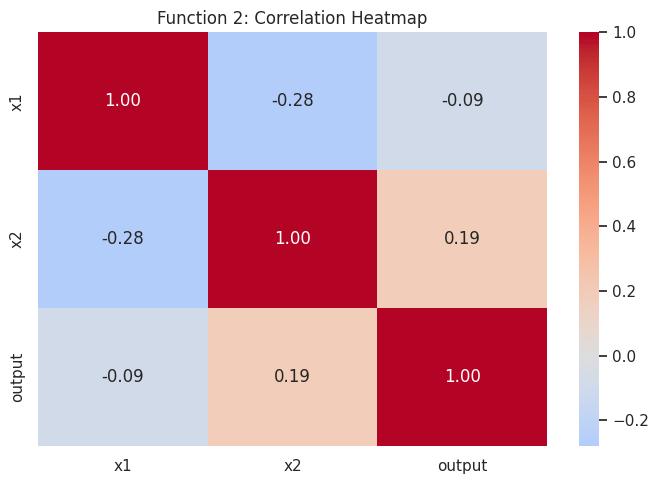

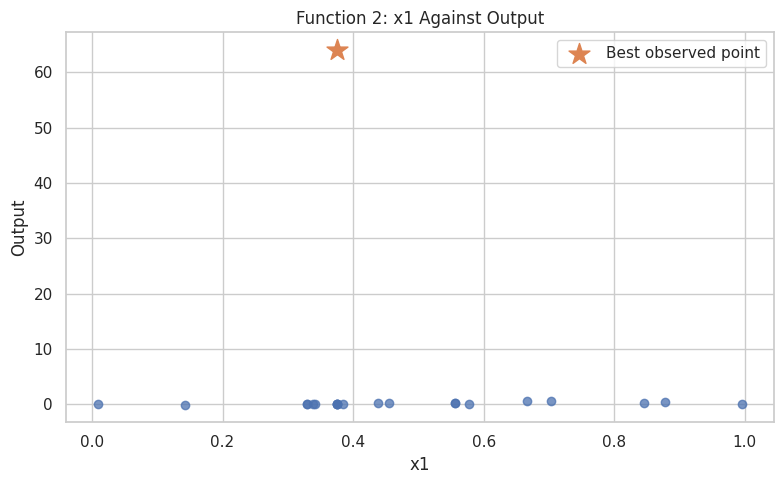

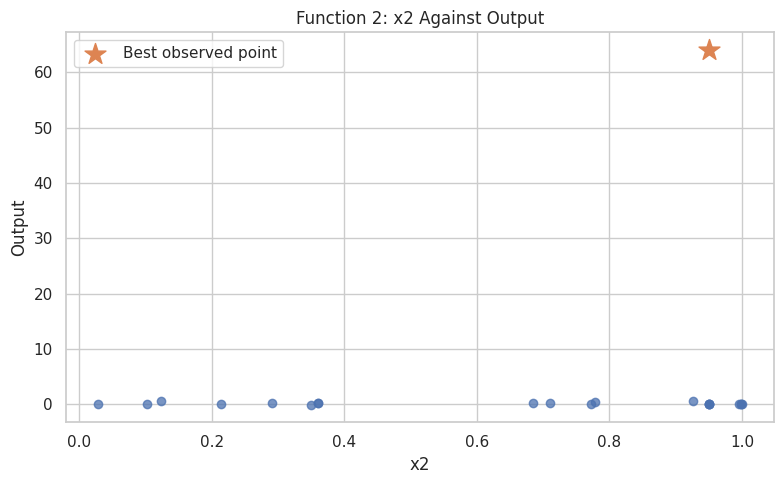


Input-output correlations
----------------------------------------
x2    0.185249
x1   -0.086422
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 22
Input dimensions   : 2
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : -0.06562362444
Mean output        : 3.044486497
Median output      : 0.04940643322
Maximum output     : 64
Best observation   : 14
Best query point   : [0.37454  0.950714]
Best output        : 64


In [78]:
# Conduct Function 2 EDA
eda_2 = conduct_function_eda(
    function_number=2,
    dataset_folder=week_12_folder
)



FUNCTION 3 EDA

Dataset structure
----------------------------------------
Input shape : (27, 3)
Output shape: (27,)
Observations: 27
Dimensions  : 3

First five observations
----------------------------------------


,x1,x2,x3,output
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008



Missing values
----------------------------------------
x1        0
x2        0
x3        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,27.0,0.430521,0.204296,0.046809,0.293819,0.444444,0.522471,0.965995,0.444444,0.041737,0.294660
x2,27.0,0.540735,0.226004,0.090709,0.370530,0.658930,0.667304,0.941360,0.658930,0.051078,-0.576448
x3,27.0,0.379193,0.212675,0.066089,0.270898,0.333333,0.397460,0.990882,0.333333,0.045231,1.687120
output,27.0,9.403907,23.201962,-0.398926,-0.108293,-0.057397,-0.039677,64.000000,-0.057397,538.331047,2.099328



Best observed result
----------------------------------------
Best array index       : 15
Best observation number: 16
Best query point       : [0.444444 0.666666 0.333333]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,output
16,0.444444,0.666666,0.333333,64.000000
17,0.444444,0.666666,0.333333,64.000000
18,0.444444,0.666666,0.333333,64.000000
15,0.444444,0.666666,0.333333,64.000000
3,0.492581,0.611593,0.340176,-0.034835


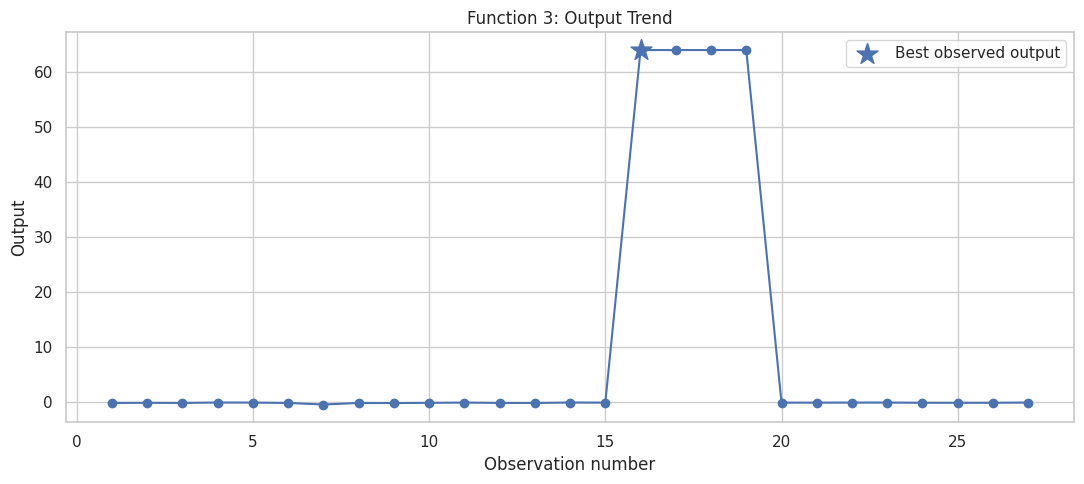

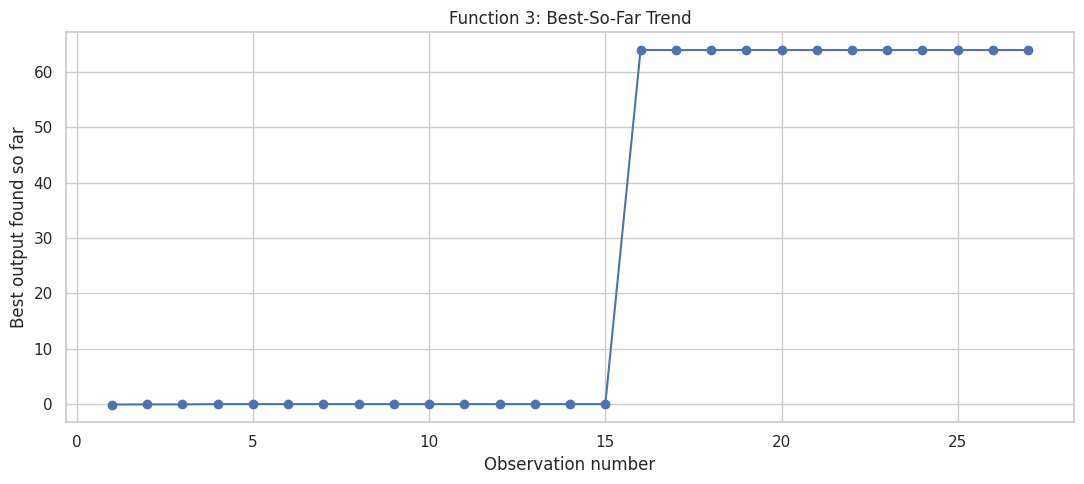

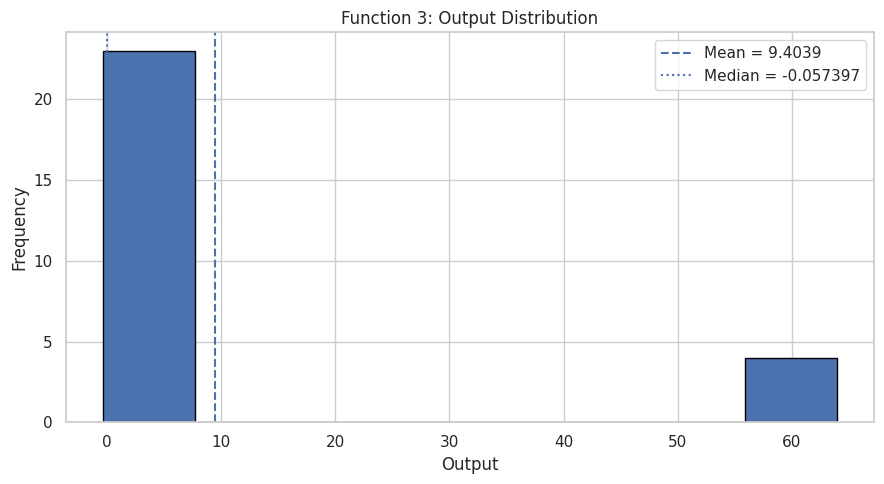

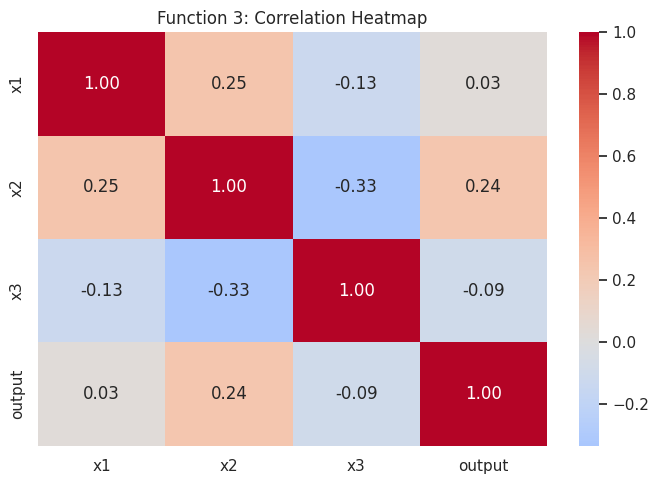

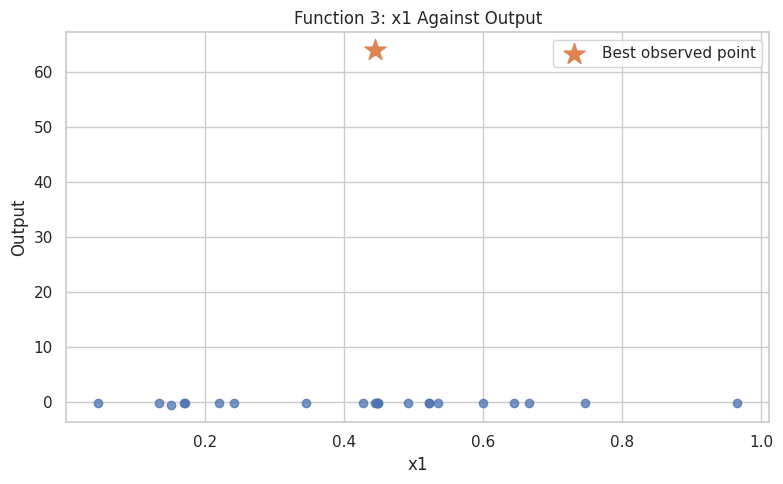

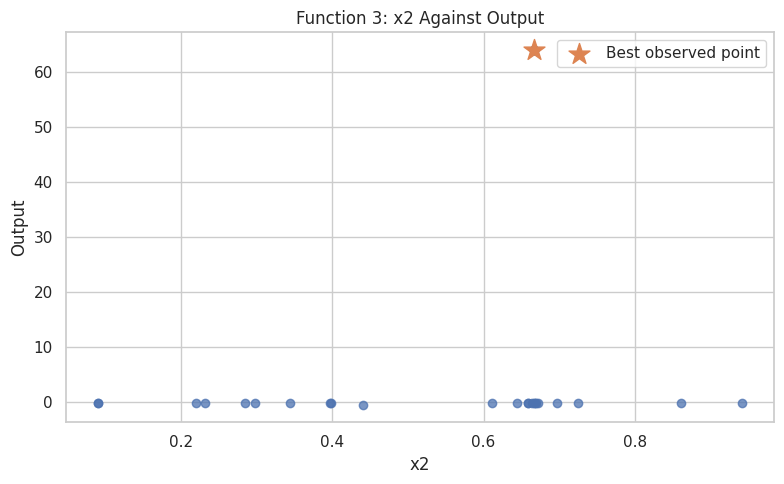

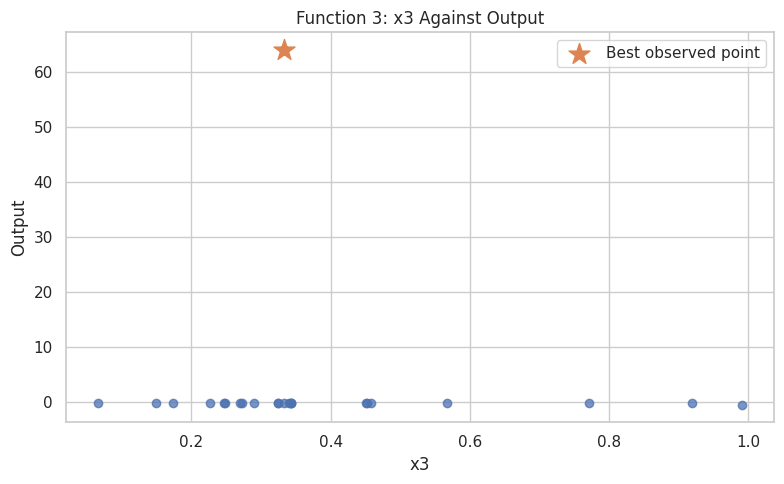


Input-output correlations
----------------------------------------
x2    0.237108
x3   -0.093255
x1    0.029755
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 27
Input dimensions   : 3
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : -0.3989255131
Mean output        : 9.403906813
Median output      : -0.05739710167
Maximum output     : 64
Best observation   : 16
Best query point   : [0.444444 0.666666 0.333333]
Best output        : 64


In [63]:
# Conduct Function 3 EDA
eda_3 = conduct_function_eda(
    function_number=3,
    dataset_folder=week_12_folder
)



FUNCTION 4 EDA

Dataset structure
----------------------------------------
Input shape : (42, 4)
Output shape: (42,)
Observations: 42
Dimensions  : 4

First five observations
----------------------------------------


,x1,x2,x3,x4,output
0,0.896981,0.725628,0.175404,0.701694,-22.108288
1,0.889356,0.499588,0.539269,0.508783,-14.601397
2,0.250946,0.033693,0.145380,0.494932,-11.699932
3,0.346962,0.006250,0.760564,0.613024,-16.053765
4,0.124871,0.129770,0.384400,0.287076,-10.069633



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,42.0,0.558583,0.268220,0.037825,0.331297,0.582847,0.744680,0.985622,0.582847,0.071942,-0.273940
x2,42.0,0.436711,0.283913,0.002958,0.174215,0.458405,0.648051,0.919592,0.458405,0.080606,0.014775
x3,42.0,0.379956,0.268506,0.014095,0.183088,0.306291,0.537084,0.939178,0.306291,0.072096,0.504043
x4,42.0,0.378026,0.308491,0.032616,0.107193,0.251466,0.679527,0.999483,0.251466,0.095167,0.524008
output,42.0,-14.364052,14.667329,-32.625660,-21.630179,-16.040082,-11.945371,64.000000,-16.040082,215.130546,3.811449



Best observed result
----------------------------------------
Best array index       : 33
Best observation number: 34
Best query point       : [0.555555 0.444444 0.222222 0.111111]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,output
33,0.555555,0.444444,0.222222,0.111111,64.000000
31,0.555555,0.444444,0.222222,0.111111,-0.031830
30,0.555555,0.444444,0.222222,0.111111,-0.031830
32,0.555555,0.444444,0.222222,0.111111,-0.031830
27,0.577766,0.428772,0.425826,0.249007,-4.025542


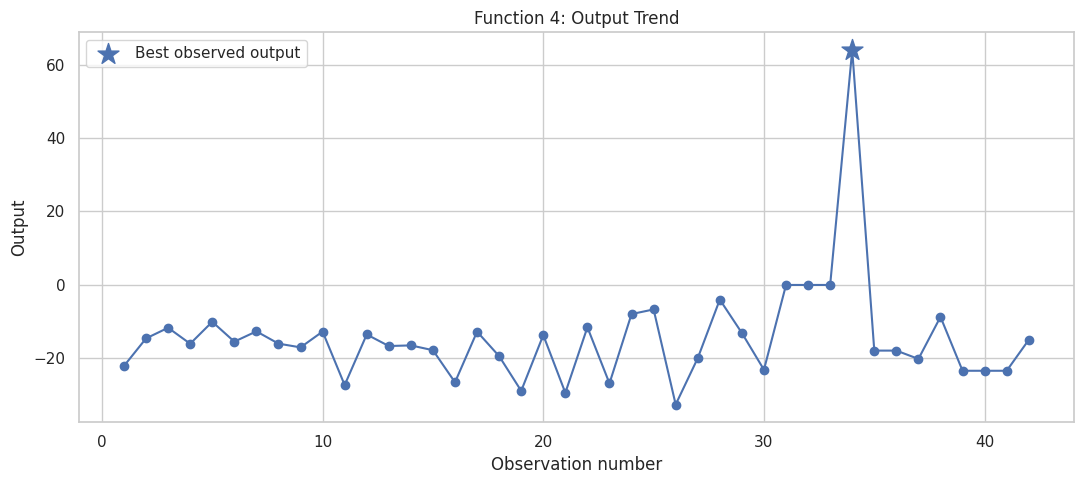

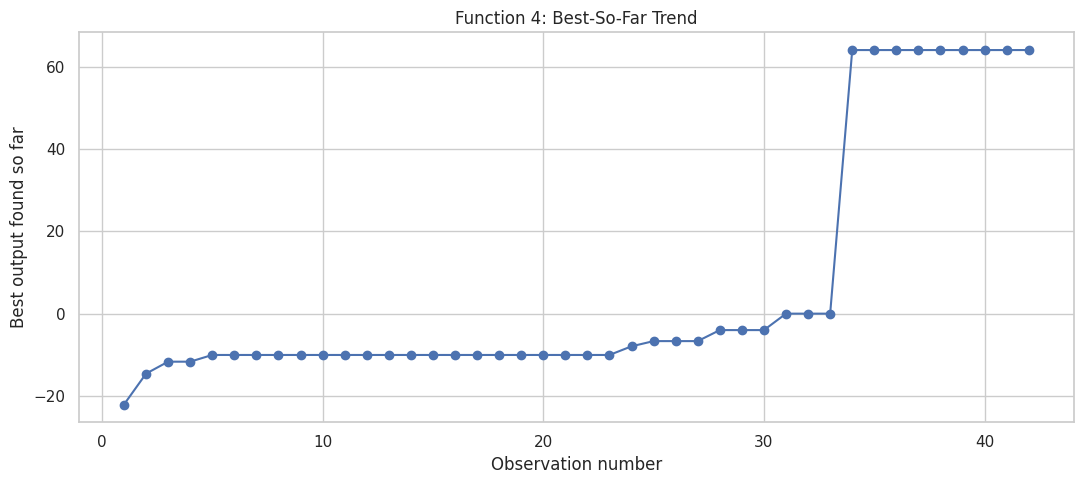

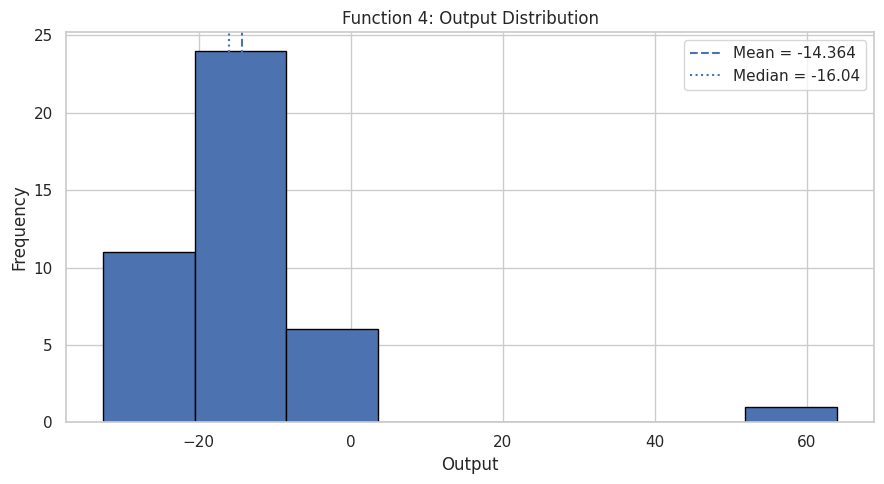

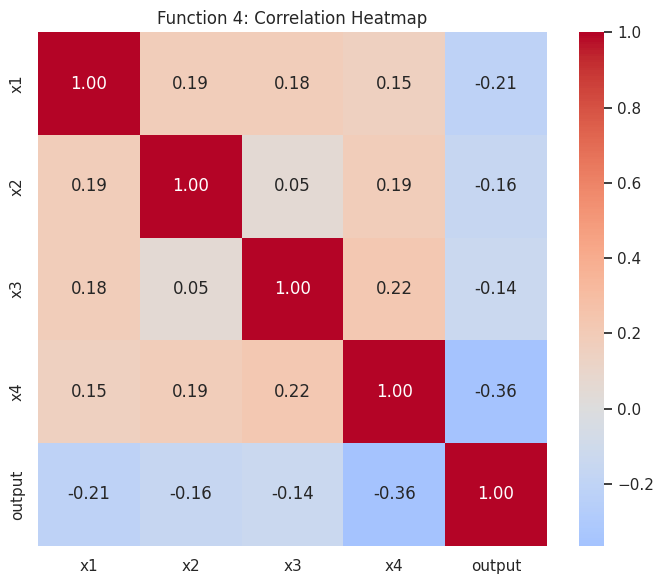

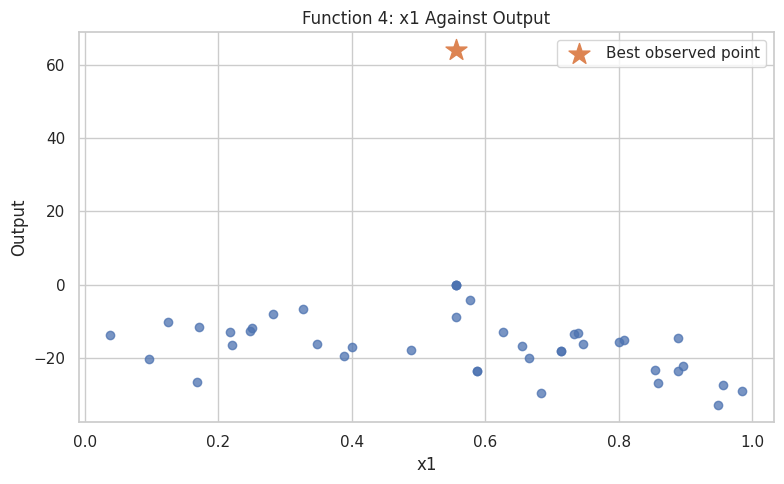

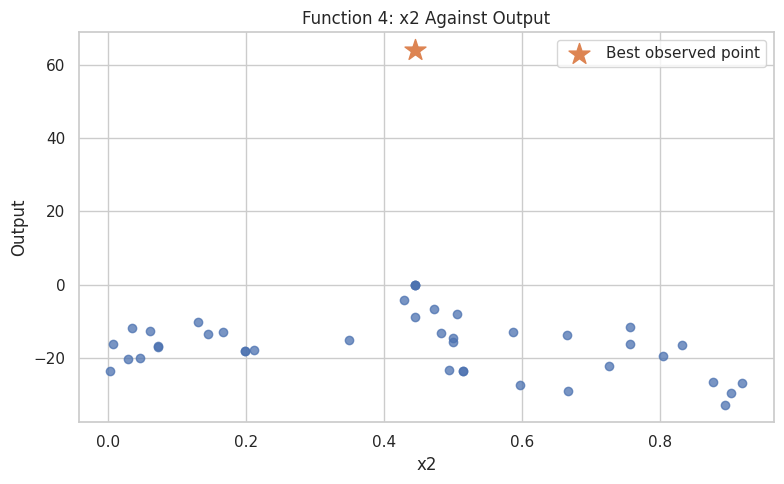

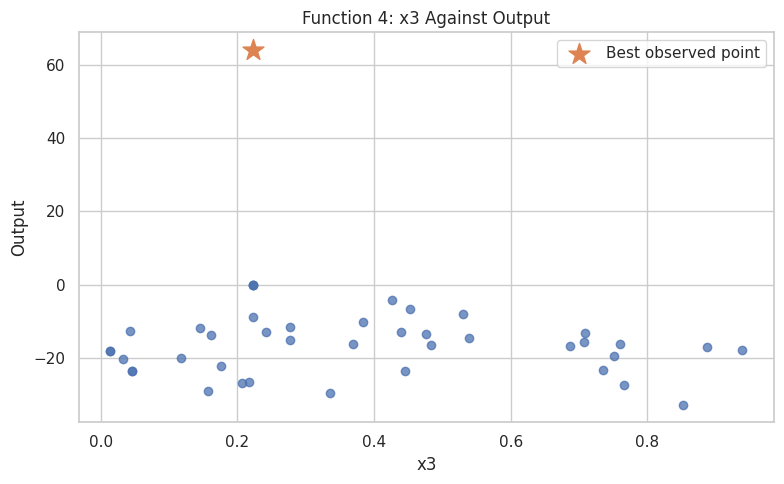

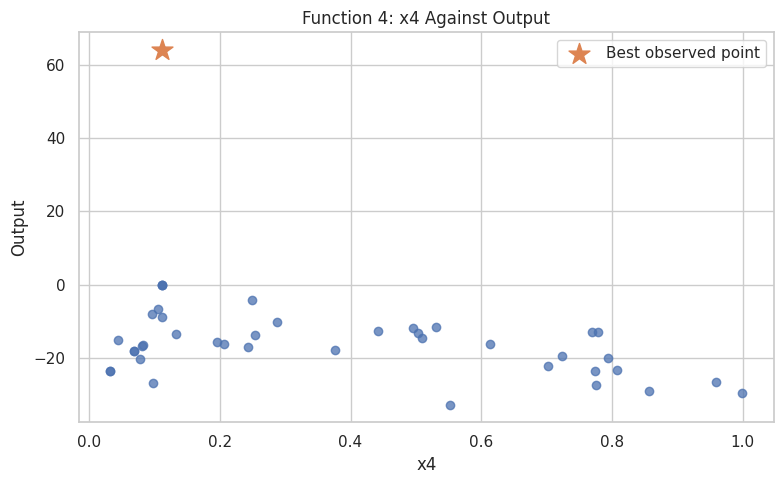


Input-output correlations
----------------------------------------
x4   -0.364153
x1   -0.210673
x2   -0.157261
x3   -0.135435
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 42
Input dimensions   : 4
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : -32.62566022
Mean output        : -14.36405163
Median output      : -16.04008244
Maximum output     : 64
Best observation   : 34
Best query point   : [0.555555 0.444444 0.222222 0.111111]
Best output        : 64


In [64]:
# Conduct Function 4 EDA
eda_4 = conduct_function_eda(
    function_number=4,
    dataset_folder=week_12_folder
)



FUNCTION 5 EDA

Dataset structure
----------------------------------------
Input shape : (32, 4)
Output shape: (32,)
Observations: 32
Dimensions  : 4

First five observations
----------------------------------------


,x1,x2,x3,x4,output
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
5

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,32.0,0.380793,0.258576,0.00000,0.216004,0.336140,0.607353,0.836478,0.336140,0.066862,0.225491
x2,32.0,0.554784,0.299544,0.00000,0.320901,0.634822,0.846480,0.918769,0.634822,0.089727,-0.542244
x3,32.0,0.540501,0.266217,0.00000,0.370650,0.615026,0.739073,0.879484,0.615026,0.070872,-0.369455
x4,32.0,0.588510,0.337546,0.00000,0.307039,0.663668,0.878515,1.000000,0.663668,0.113937,-0.323660
output,32.0,188.679420,275.570030,0.11294,27.755836,64.210073,239.510339,1088.859618,64.210073,75938.841161,2.380534



Best observed result
----------------------------------------
Best array index       : 15
Best observation number: 16
Best query point       : [0.22418902 0.84648049 0.87948418 0.87851568]
Best output value      : 1088.8596181962705

Top five observations
----------------------------------------


,x1,x2,x3,x4,output
15,0.224189,0.846480,0.879484,0.878516,1088.859618
27,0.224189,0.846480,0.879484,0.878515,1088.853511
18,0.119879,0.862540,0.643331,0.849804,431.612757
30,0.005552,0.918769,0.692571,0.988052,430.803125
29,0.005552,0.918769,0.692571,0.988052,430.803125


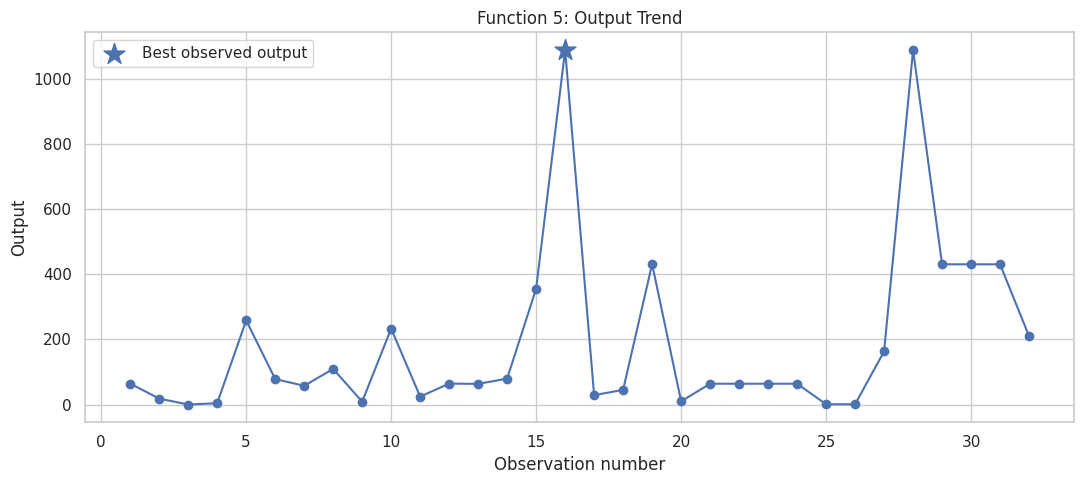

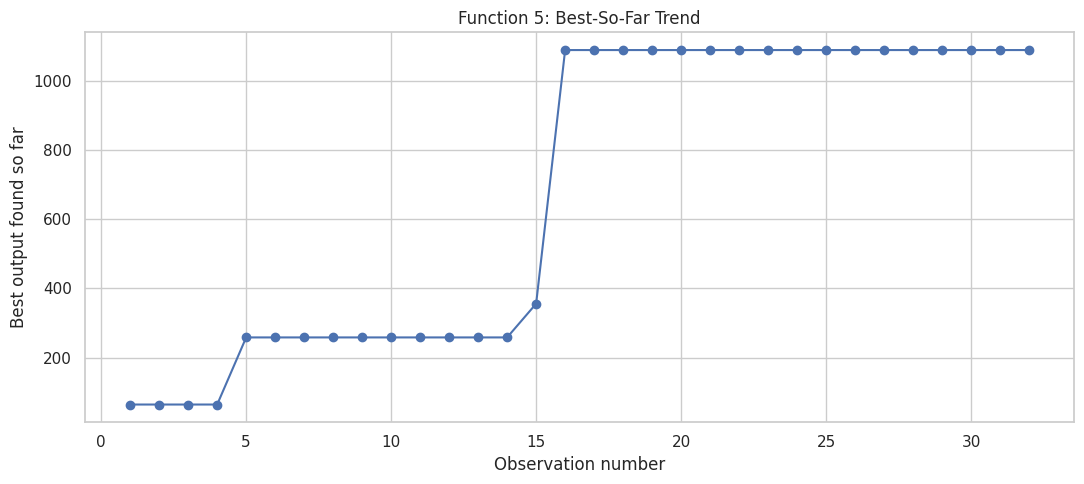

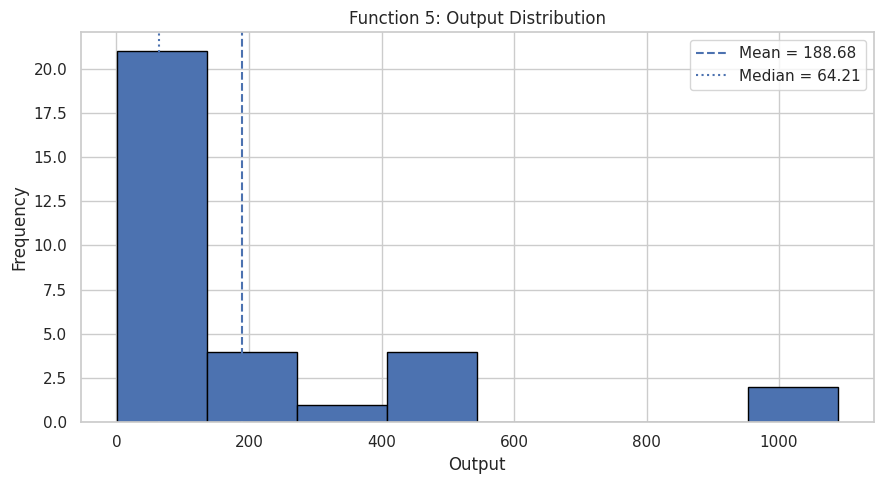

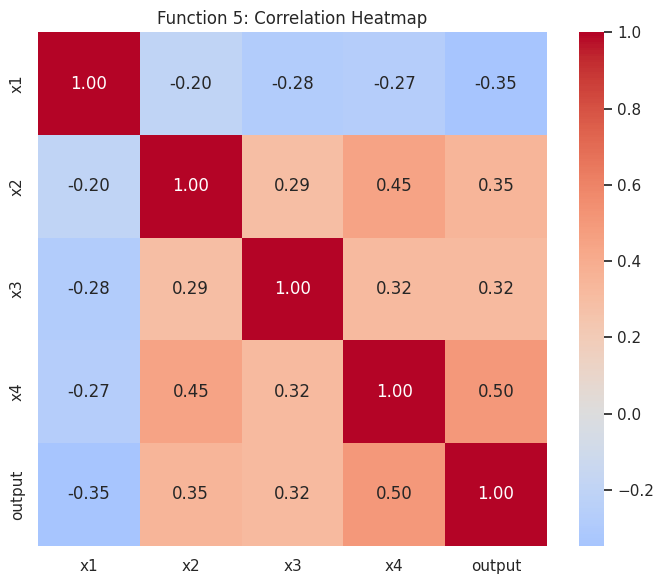

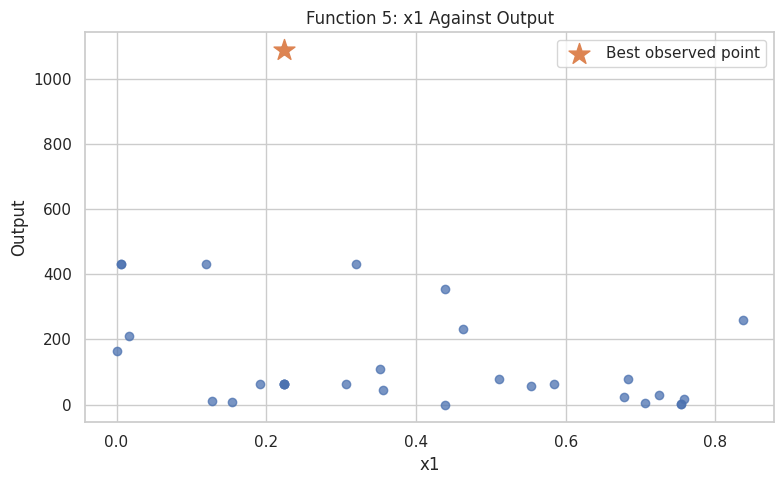

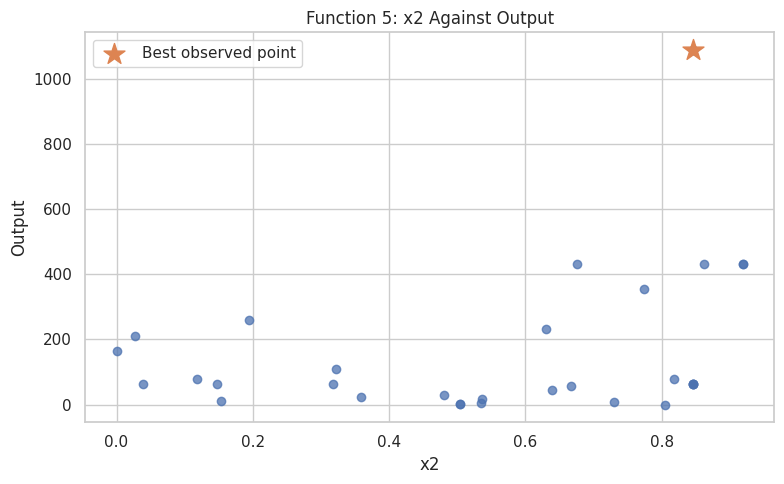

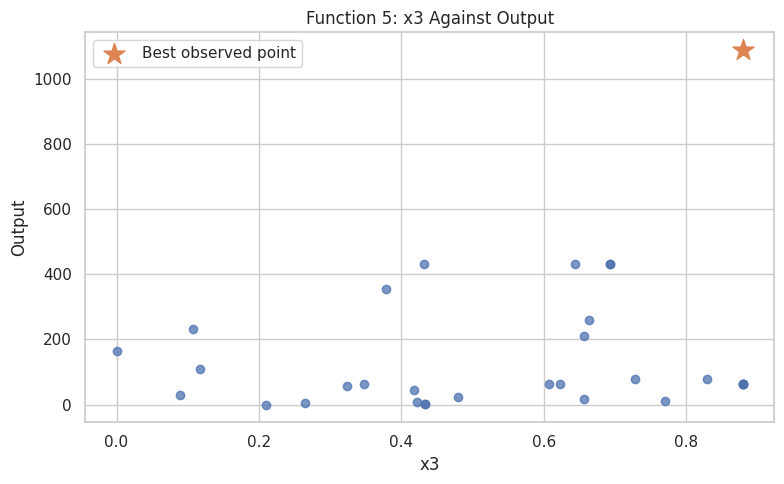

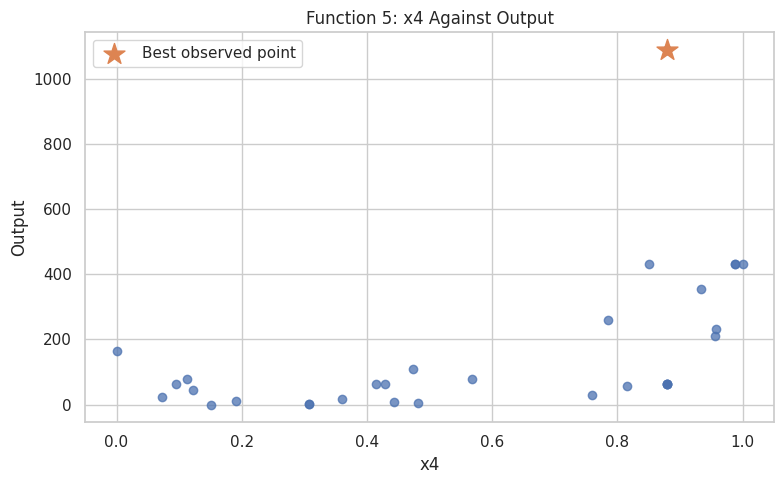


Input-output correlations
----------------------------------------
x4    0.502771
x2    0.350300
x1   -0.347029
x3    0.316943
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 32
Input dimensions   : 4
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 5
Minimum output     : 0.1129397954
Mean output        : 188.6794202
Median output      : 64.21007341
Maximum output     : 1088.859618
Best observation   : 16
Best query point   : [0.22418902 0.84648049 0.87948418 0.87851568]
Best output        : 1088.859618


In [65]:
# Conduct Function 5 EDA
eda_5 = conduct_function_eda(
    function_number=5,
    dataset_folder=week_12_folder
)



FUNCTION 6 EDA

Dataset structure
----------------------------------------
Input shape : (32, 5)
Output shape: (32,)
Observations: 32
Dimensions  : 5

First five observations
----------------------------------------


,x1,x2,x3,x4,x5,output
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,32.0,0.625781,0.261159,0.021735,0.512434,0.728186,0.783399,0.957740,0.728186,0.068204,-1.052915
x2,32.0,0.397813,0.311801,0.022732,0.154693,0.289965,0.723740,0.931871,0.289965,0.097220,0.576320
x3,32.0,0.580527,0.293239,0.016523,0.414127,0.704408,0.734013,0.978806,0.704408,0.085989,-0.766922
x4,32.0,0.546783,0.266434,0.041715,0.380307,0.679768,0.696748,0.961656,0.679768,0.070987,-0.687282
x5,32.0,0.503404,0.265610,0.004911,0.315013,0.564013,0.618549,0.897560,0.564013,0.070549,-0.540433
output,32.0,0.681314,11.571848,-2.571170,-1.696397,-1.267069,-1.150223,64.000000,-1.267069,133.907659,5.629542



Best observed result
----------------------------------------
Best array index       : 23
Best observation number: 24
Best query point       : [0.728186 0.154693 0.732552 0.693997 0.564013]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,x5,output
23,0.728186,0.154693,0.732552,0.693997,0.564013,64.000000
21,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
22,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
20,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265


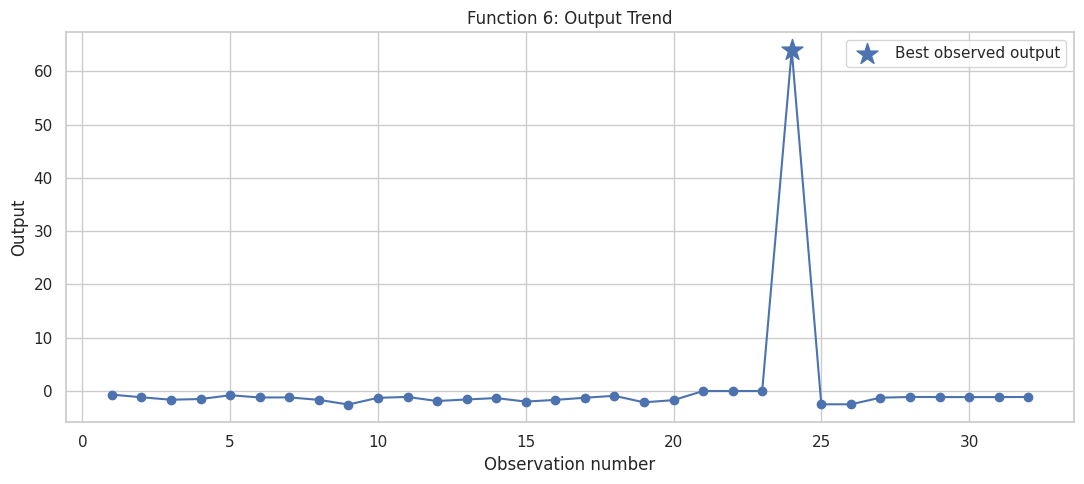

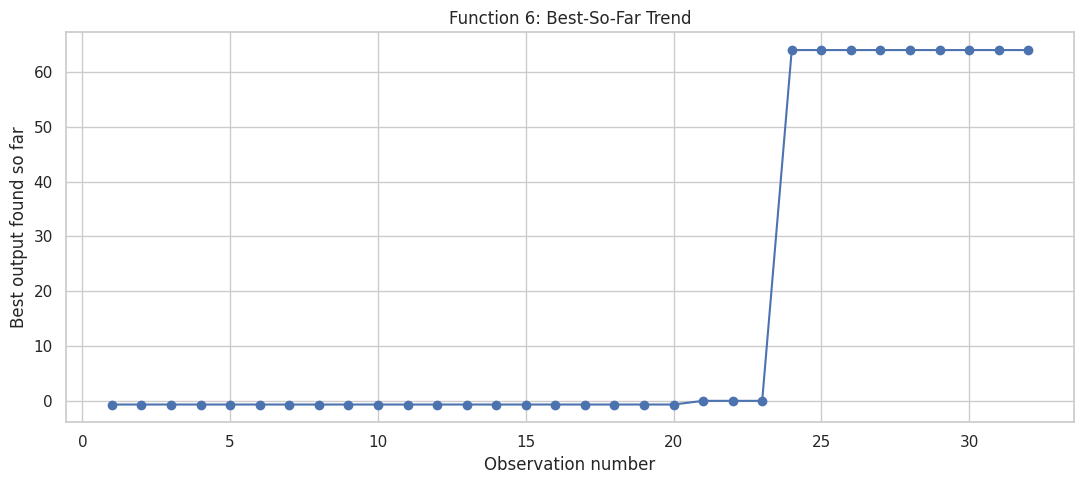

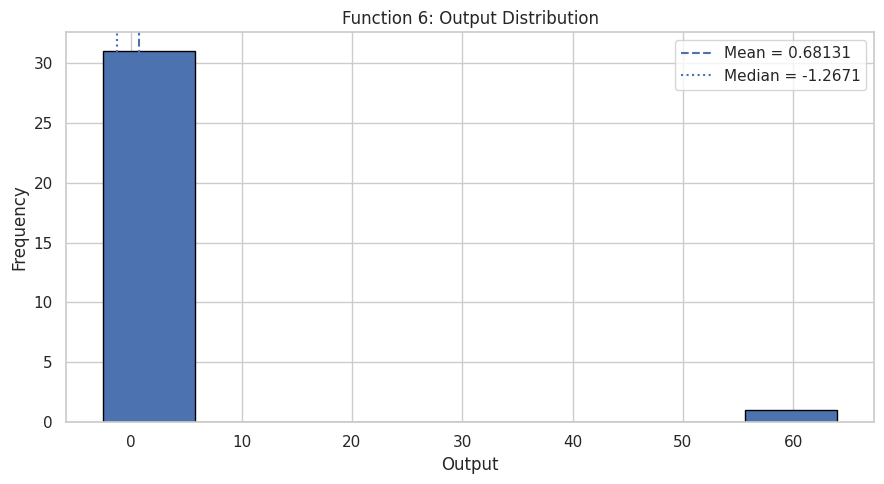

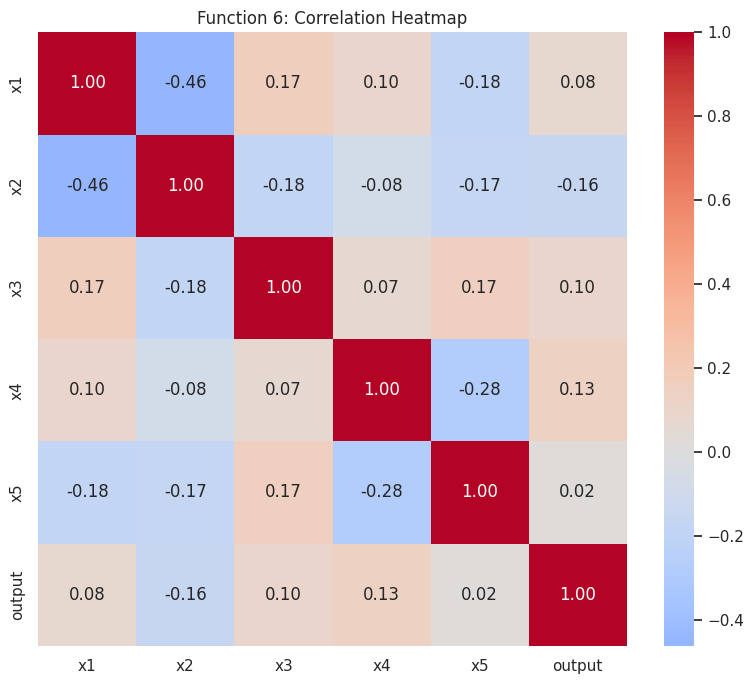

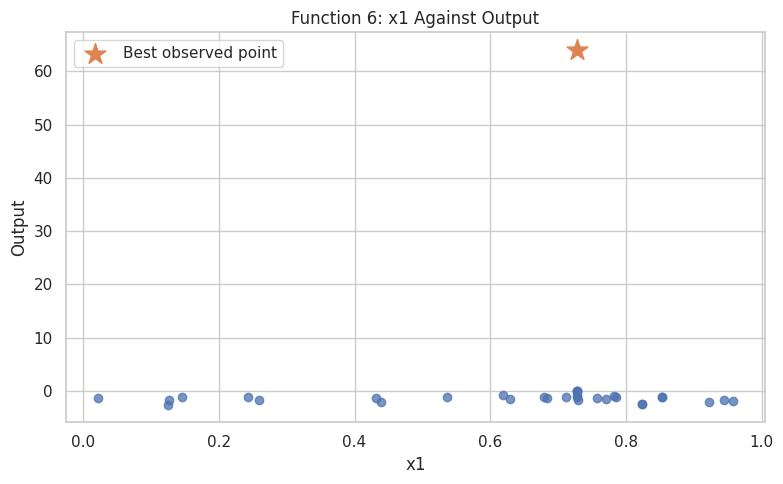

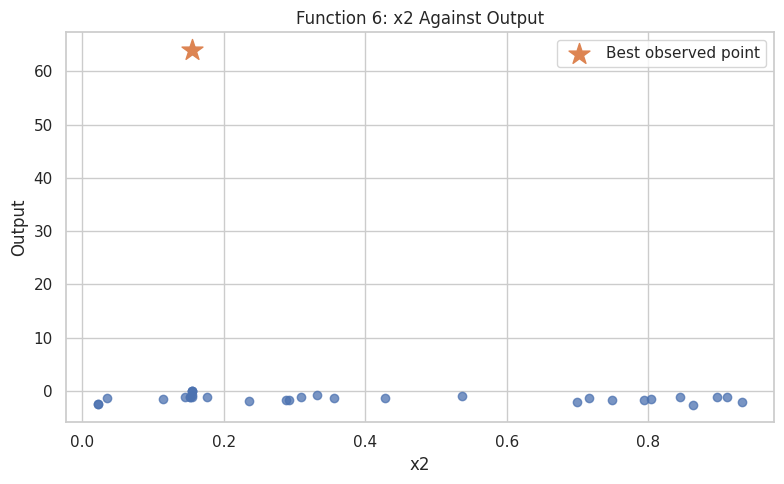

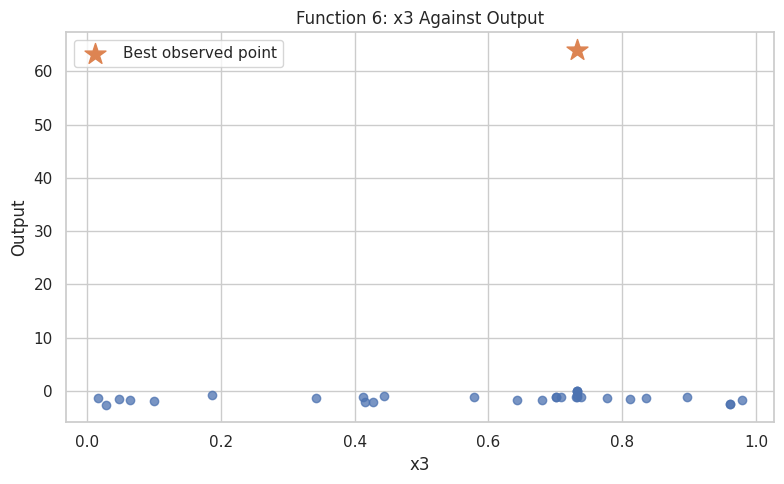

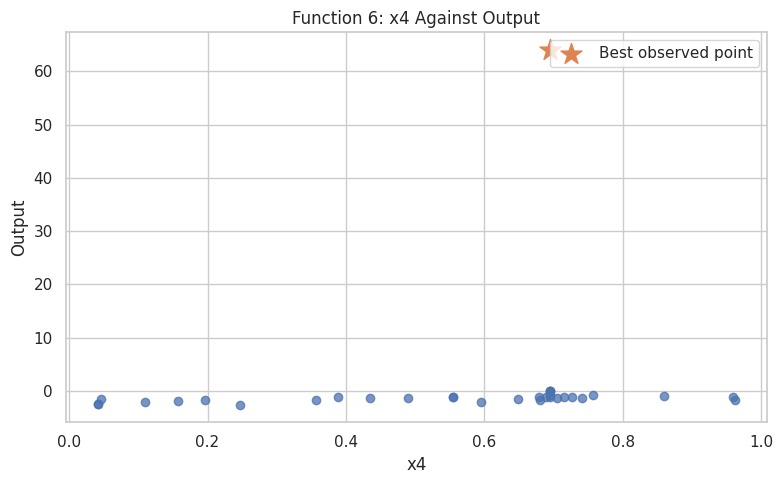

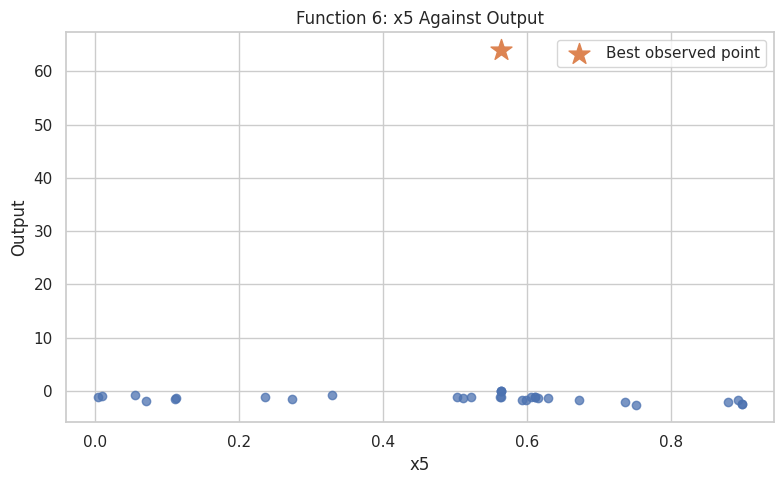


Input-output correlations
----------------------------------------
x2   -0.156502
x4    0.134182
x3    0.102865
x1    0.077245
x5    0.021728
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 32
Input dimensions   : 5
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : -2.571169632
Mean output        : 0.6813141195
Median output      : -1.267069193
Maximum output     : 64
Best observation   : 24
Best query point   : [0.728186 0.154693 0.732552 0.693997 0.564013]
Best output        : 64


In [66]:
# Conduct Function 6 EDA
eda_6 = conduct_function_eda(
    function_number=6,
    dataset_folder=week_12_folder
)



FUNCTION 7 EDA

Dataset structure
----------------------------------------
Input shape : (42, 6)
Output shape: (42,)
Observations: 42
Dimensions  : 6

First five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,output
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,42.0,0.387244,0.325371,0.018603,0.079457,0.276768,0.713675,0.942451,0.276768,0.105866,0.378328
x2,42.0,0.456588,0.245531,0.011813,0.324216,0.516186,0.598333,0.924694,0.516186,0.060286,-0.059467
x3,42.0,0.390252,0.276562,0.003635,0.246107,0.329265,0.600719,0.924571,0.329265,0.076486,0.431925
x4,42.0,0.396239,0.322491,0.037758,0.110105,0.243684,0.710543,0.961017,0.243684,0.104000,0.639546
x5,42.0,0.454488,0.265797,0.014944,0.264614,0.434667,0.671163,0.998655,0.434667,0.070648,0.285040
x6,42.0,0.521781,0.236248,0.051100,0.360685,0.626393,0.664673,0.951014,0.626393,0.055813,-0.731722
output,42.0,6.414965,18.913824,0.002701,0.035703,0.198546,0.843747,64.000000,0.198546,357.732746,2.858574



Best observed result
----------------------------------------
Best array index       : 30
Best observation number: 31
Best query point       : [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,output
31,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
30,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
33,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
32,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
41,0.280913,0.512275,0.321637,0.188234,0.420546,0.641027,1.478174


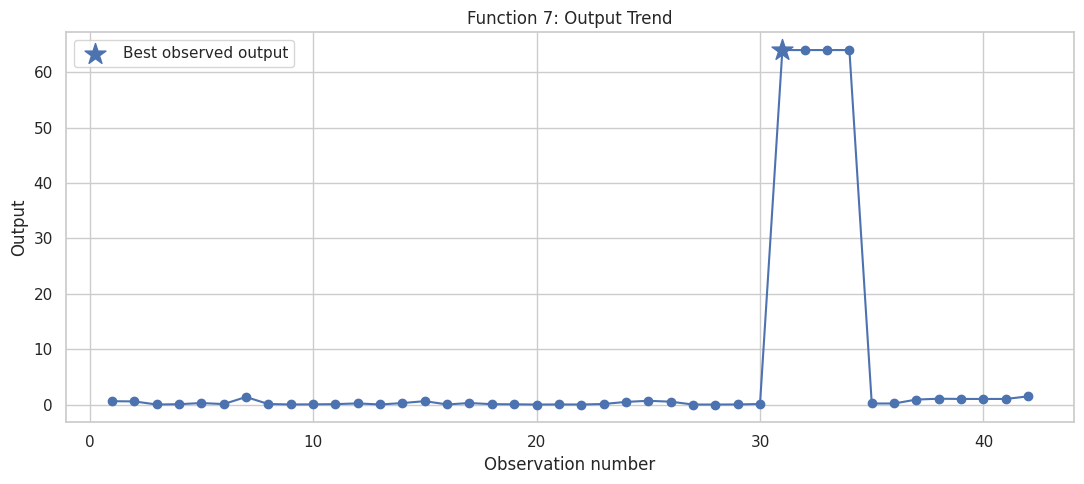

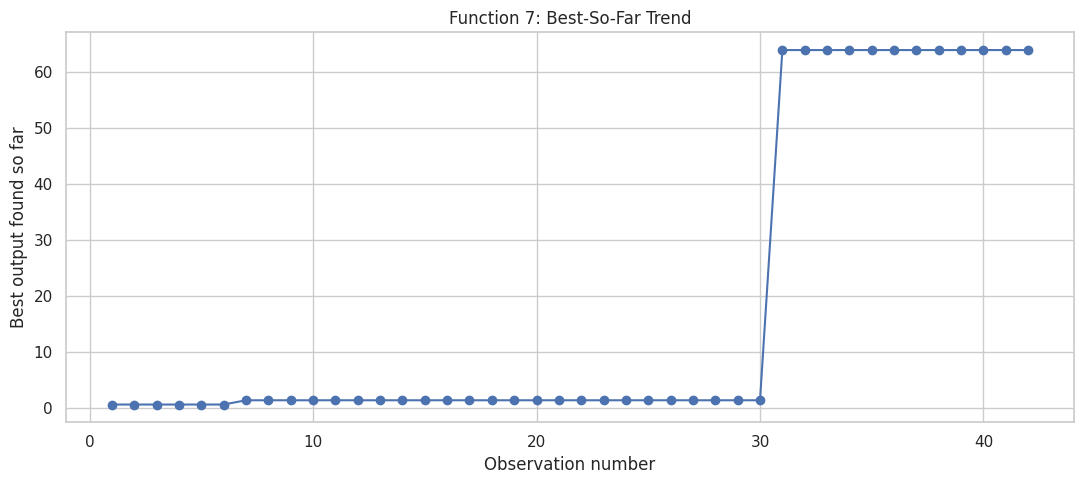

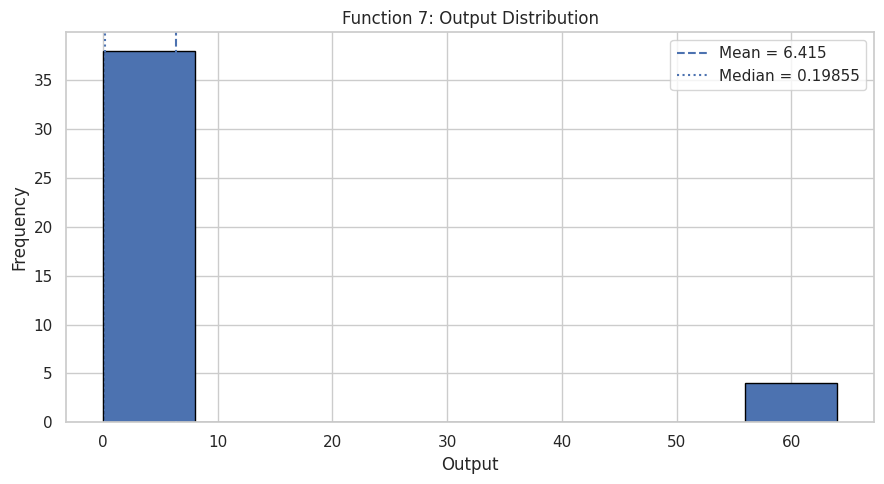

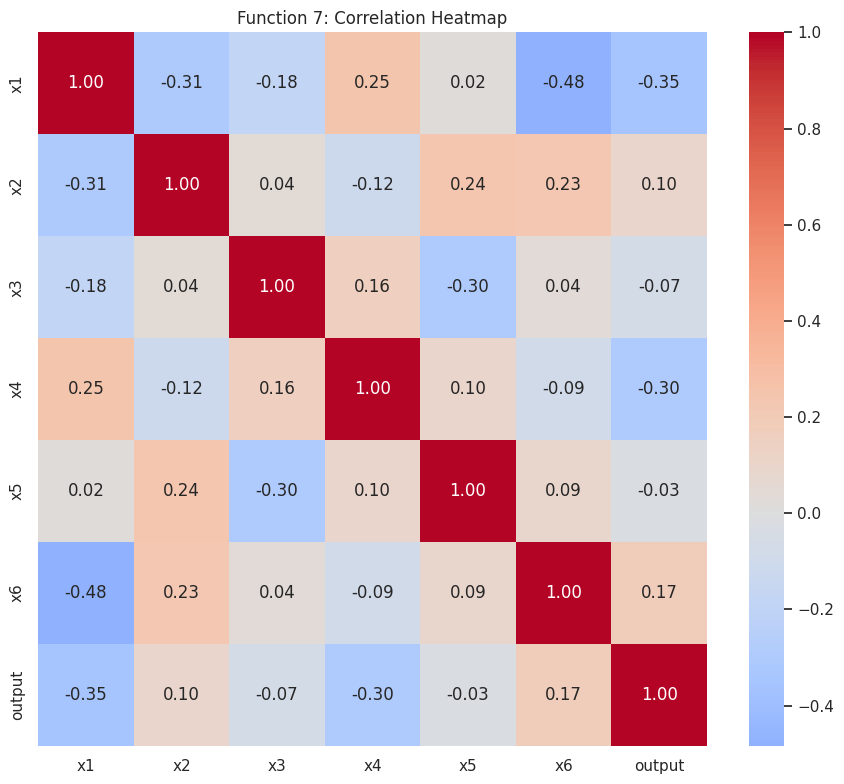

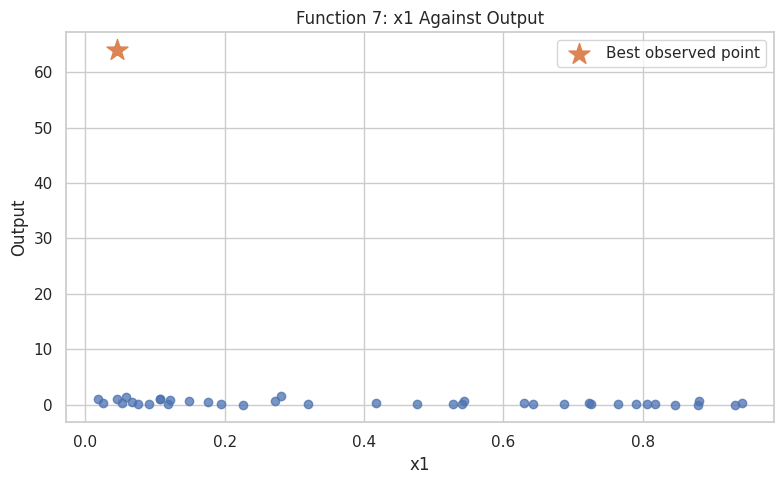

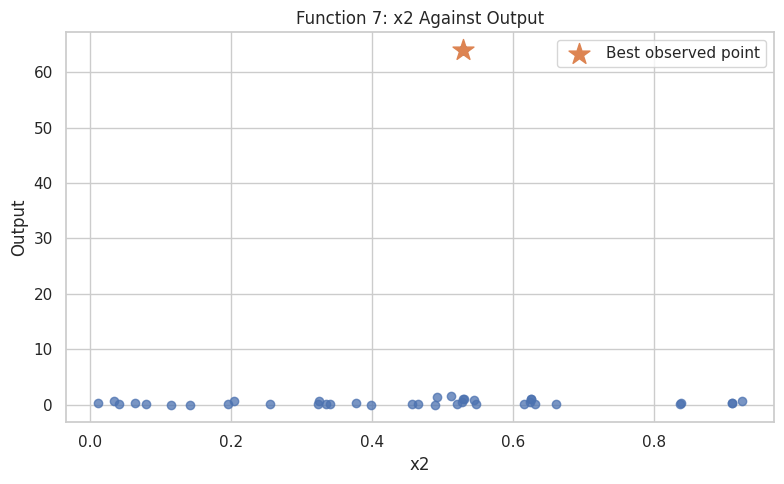

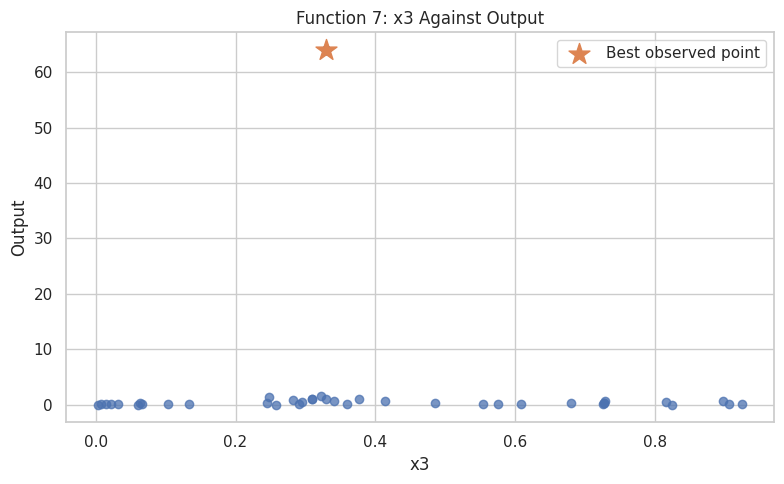

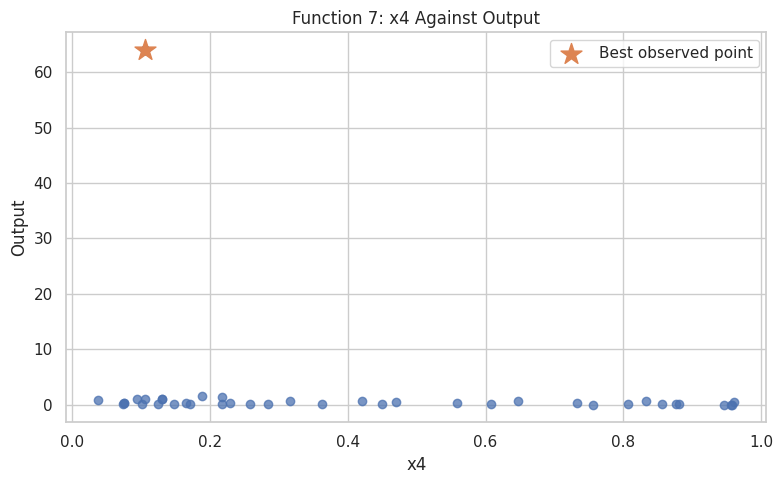

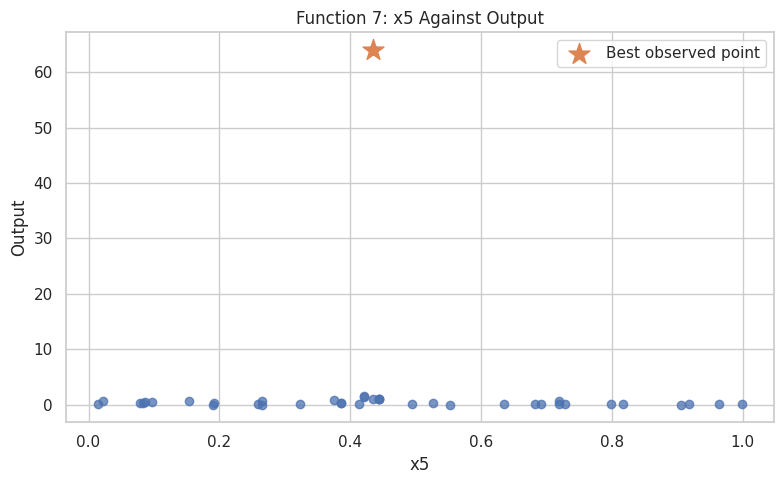

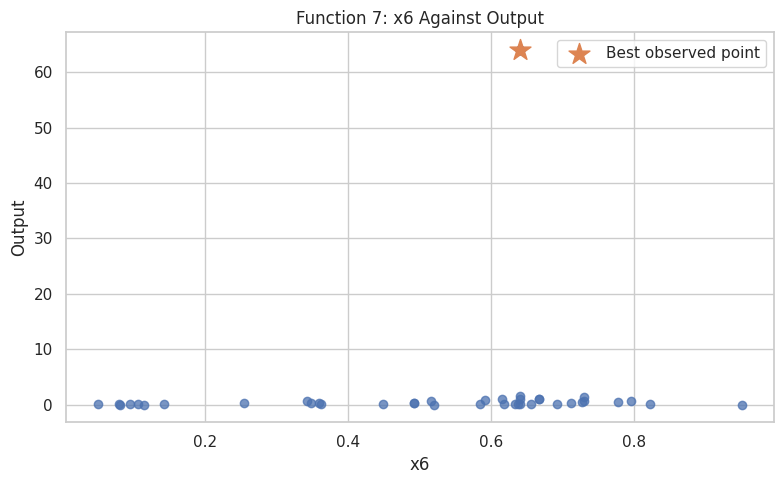


Input-output correlations
----------------------------------------
x1   -0.354847
x4   -0.303149
x6    0.173563
x2    0.099720
x3   -0.071950
x5   -0.030333
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 42
Input dimensions   : 6
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : 0.002701465025
Mean output        : 6.414964967
Median output      : 0.1985461626
Maximum output     : 64
Best observation   : 31
Best query point   : [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Best output        : 64


In [67]:
# Conduct Function 7 EDA
eda_7 = conduct_function_eda(
    function_number=7,
    dataset_folder=week_12_folder
)



FUNCTION 8 EDA

Dataset structure
----------------------------------------
Input shape : (51, 8)
Output shape: (51,)
Observations: 51
Dimensions  : 8

First five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,x7,x8,output
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
x7        0
x8        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
x7        0
x8        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,51.0,0.479056,0.304094,0.006802,0.253999,0.472071,0.774131,0.985945,0.472071,0.092473,0.103926
x2,51.0,0.432007,0.296131,0.003419,0.207907,0.331802,0.646312,0.973980,0.331802,0.087694,0.253438
x3,51.0,0.447084,0.307631,0.021301,0.183284,0.382124,0.724607,0.998885,0.382124,0.094637,0.337786
x4,51.0,0.384065,0.276667,0.000000,0.088739,0.387609,0.626163,0.902986,0.387609,0.076544,0.206584
x5,51.0,0.535989,0.291336,0.009649,0.264321,0.659452,0.783945,0.986902,0.659452,0.084877,-0.208553
x6,51.0,0.412203,0.281245,0.022113,0.230729,0.289207,0.638503,0.990244,0.289207,0.079099,0.558416
x7,51.0,0.497306,0.294117,0.035909,0.199227,0.551347,0.752400,0.992914,0.551347,0.086505,-0.094337
x8,51.0,0.443625,0.282305,0.041956,0.161813,0.374340,0.668942,0.988755,0.374340,0.079696,0.297645
output,51.0,8.149903,8.971868,-8.727516,7.215748,7.977685,8.903650,64.000000,7.977685,80.494424,4.604836



Best observed result
----------------------------------------
Best array index       : 43
Best observation number: 44
Best query point       : [0.273673 0.2604   0.073937 0.078562 0.862321 0.230729 0.108688 0.110992]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,x7,x8,output
43,0.273673,0.260400,0.073937,0.078562,0.862321,0.230729,0.108688,0.110992,64.000000
48,0.546897,0.163123,0.136484,0.078398,0.771803,0.070794,0.119397,0.111488,9.699892
47,0.321258,0.232284,0.021301,0.000000,0.895967,0.249315,0.054463,0.073967,9.699892
49,0.546897,0.163123,0.136484,0.078398,0.771803,0.070794,0.119397,0.111488,9.699892
14,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482


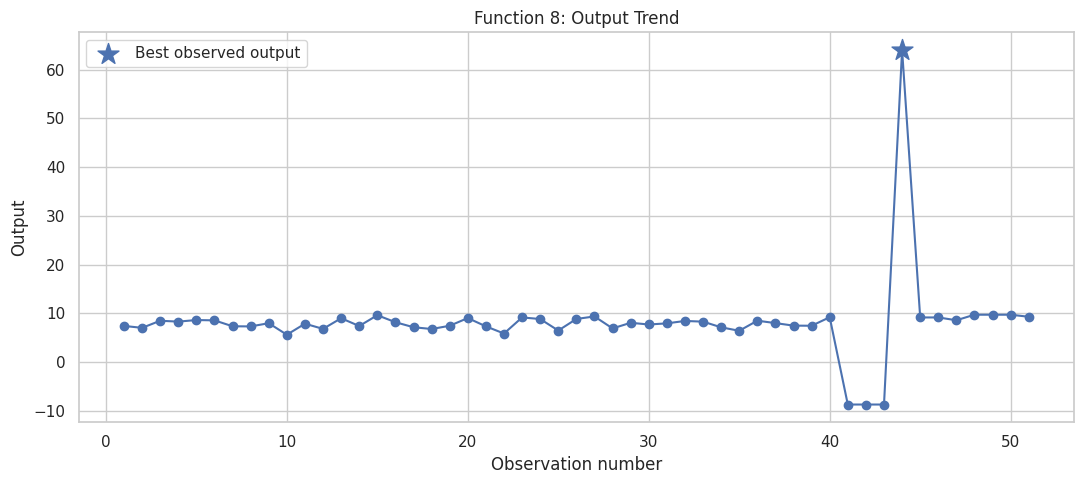

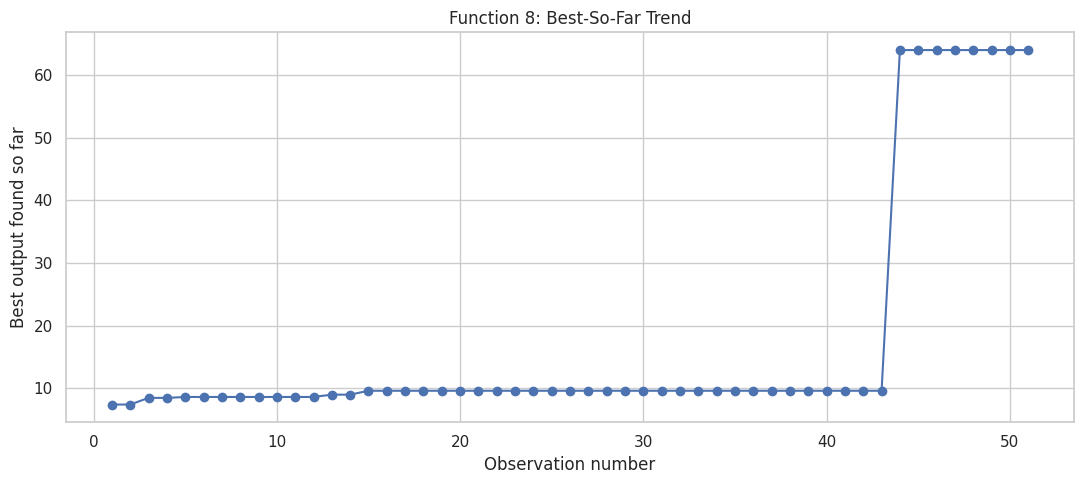

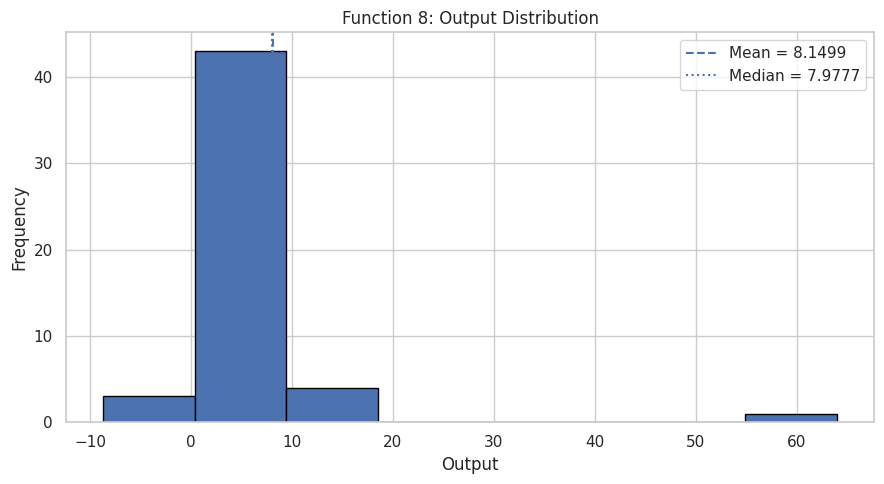

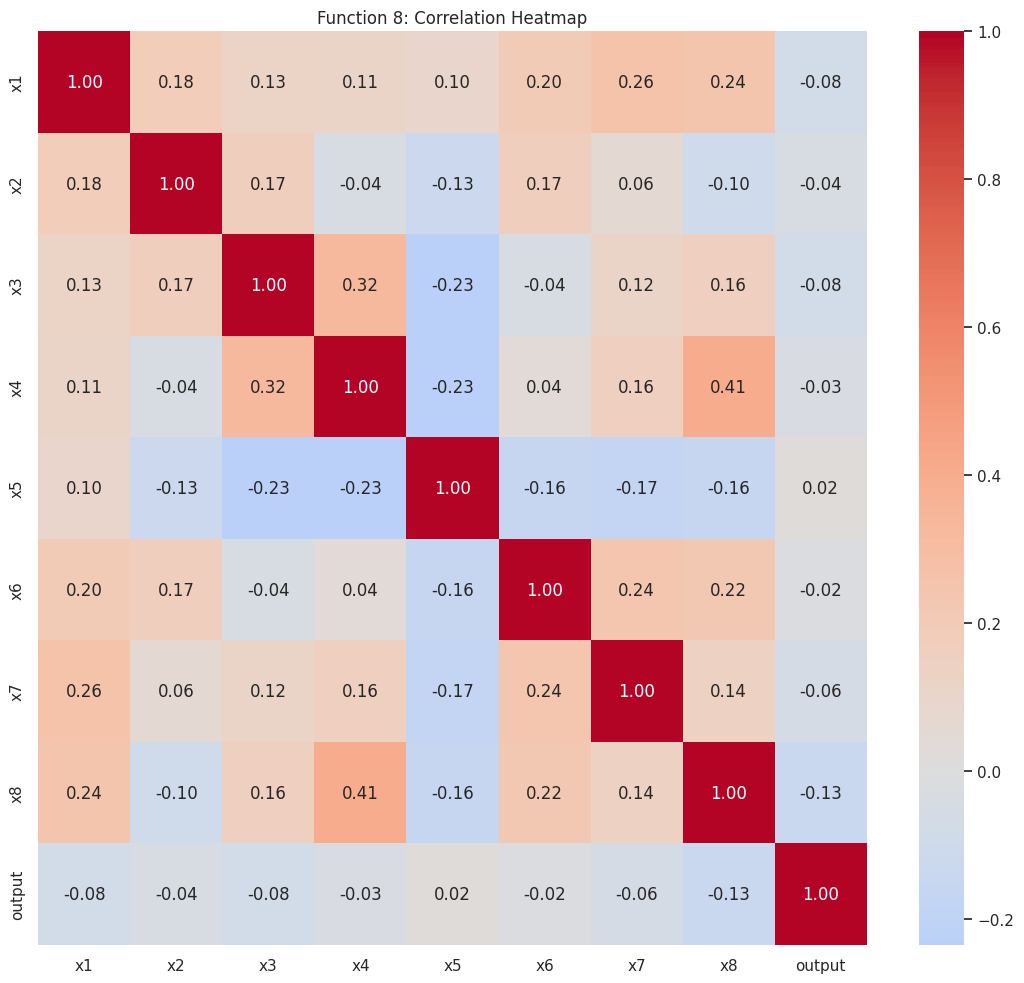

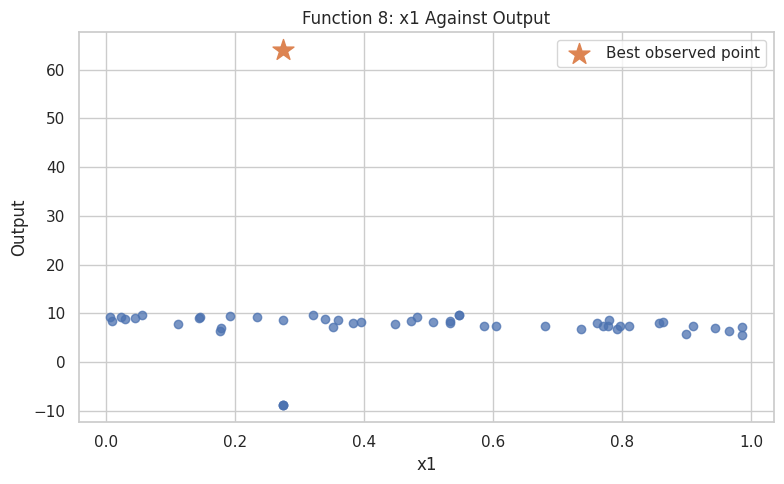

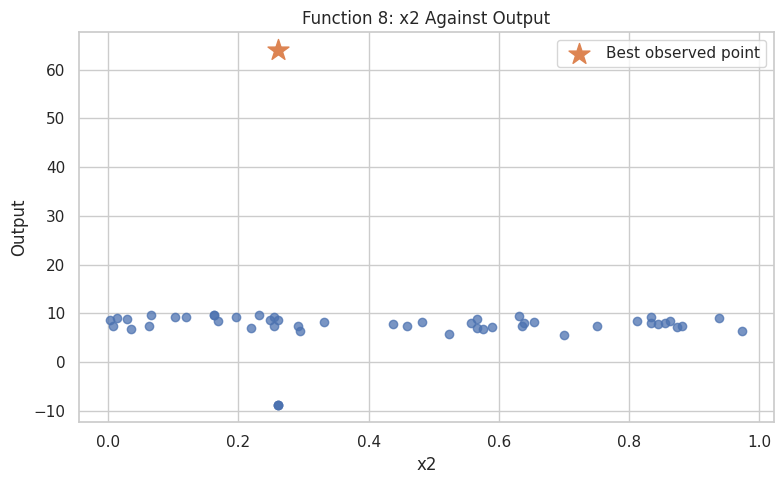

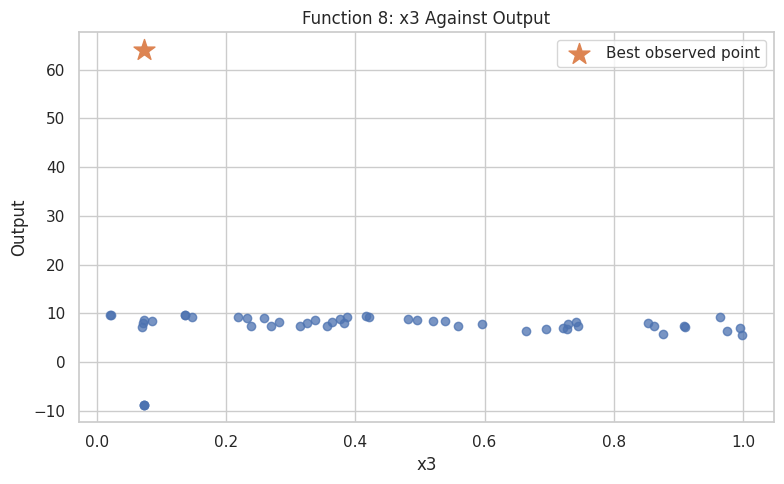

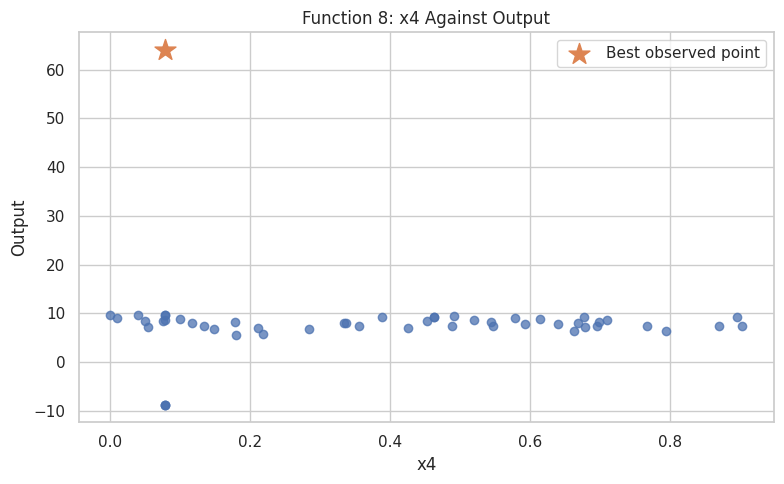

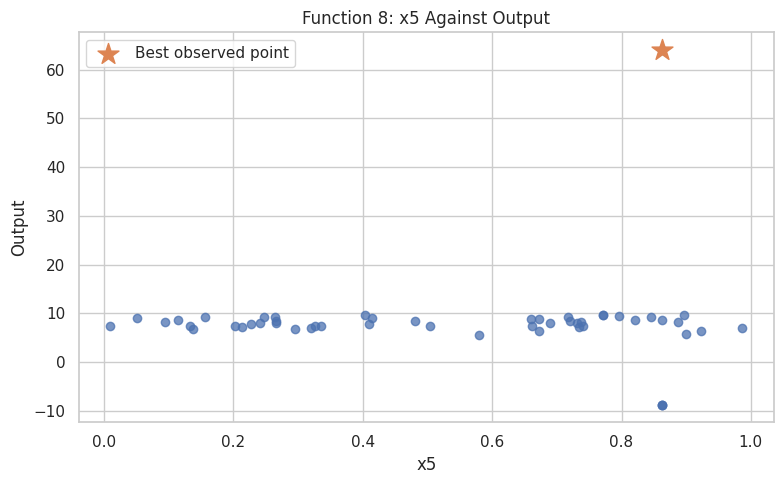

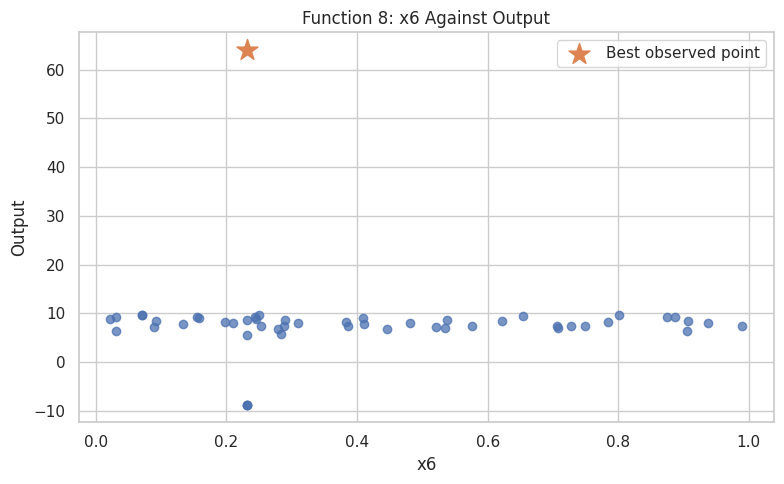

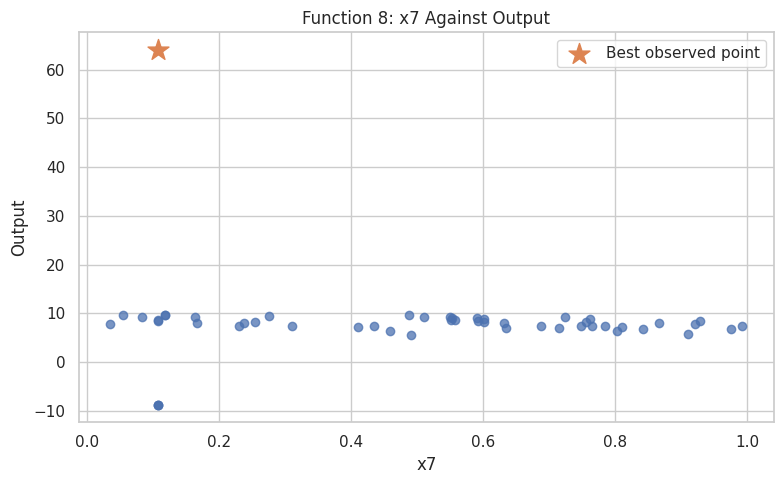

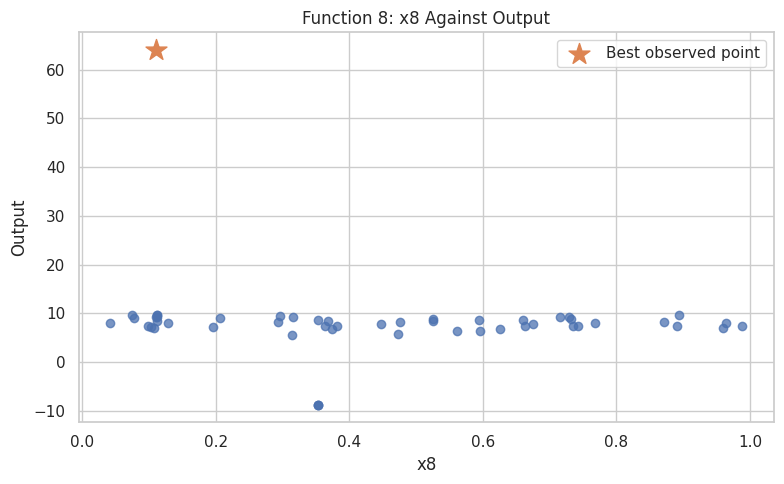


Input-output correlations
----------------------------------------
x8   -0.132027
x3   -0.080279
x1   -0.076238
x7   -0.061073
x2   -0.040764
x4   -0.031607
x6   -0.019611
x5    0.019132
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 51
Input dimensions   : 8
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : -8.727516493
Mean output        : 8.149902562
Median output      : 7.977684585
Maximum output     : 64
Best observation   : 44
Best query point   : [0.273673 0.2604   0.073937 0.078562 0.862321 0.230729 0.108688 0.110992]
Best output        : 64


In [68]:
# Conduct Function 8 EDA
eda_8 = conduct_function_eda(
    function_number=8,
    dataset_folder=week_12_folder
)

In [69]:
all_eda_results = [
    eda_1,
    eda_2,
    eda_3,
    eda_4,
    eda_5,
    eda_6,
    eda_7,
    eda_8
]

combined_summary = []

for result in all_eda_results:

    X = result["X"]
    y = result["y"]

    combined_summary.append({
        "Function": result["function"],
        "Observations": X.shape[0],
        "Dimensions": X.shape[1],
        "Minimum_Output": np.min(y),
        "Mean_Output": np.mean(y),
        "Median_Output": np.median(y),
        "Maximum_Output": np.max(y),
        "Best_Observation": result["best_index"] + 1,
        "Best_Query_Point": result["best_input"],
        "Best_Output": result["best_output"]
    })

combined_summary_df = pd.DataFrame(combined_summary)

display(combined_summary_df)

,Function,Observations,Dimensions,Minimum_Output,Mean_Output,Median_Output,Maximum_Output,Best_Observation,Best_Query_Point,Best_Output
0,1,22,2,-0.003606,11.636200,1.670890e-124,64.000000,11,"[0.37454, 0.950714]",64.000000
1,2,22,2,-0.065624,3.044486,4.940643e-02,64.000000,14,"[0.37454, 0.950714]",64.000000
2,3,27,3,-0.398926,9.403907,-5.739710e-02,64.000000,16,"[0.444444, 0.666666, 0.333333]",64.000000
3,4,42,4,-32.625660,-14.364052,-1.604008e+01,64.000000,34,"[0.555555, 0.444444, 0.222222, 0.111111]",64.000000
4,5,32,4,0.112940,188.679420,6.421007e+01,1088.859618,16,"[0.22418902330288348, 0.8464804904862864, 0.87...",1088.859618
5,6,32,5,-2.571170,0.681314,-1.267069e+00,64.000000,24,"[0.728186, 0.154693, 0.732552, 0.693997, 0.564...",64.000000
6,7,42,6,0.002701,6.414965,1.985462e-01,64.000000,31,"[0.045091, 0.528666, 0.329265, 0.10535, 0.4346...",64.000000
7,8,51,8,-8.727516,8.149903,7.977685e+00,64.000000,44,"[0.273673, 0.2604, 0.073937, 0.078562, 0.86232...",64.000000


In [70]:
# Import the required Gaussian Process classes.
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    Matern,
    WhiteKernel,
)


Define the UCB acquisition function

For maximisation, UCB is:

 UCB(x)=mu(x)+ kappasigma(x)

where:

* mu(x) is the GP-predicted mean;
* sigma(x) is the GP uncertainty;
* κappa controls exploration;
* a larger κappa produces more exploration;
* a smaller κappa produces more exploitation.

In [71]:
def upper_confidence_bound(mean, std, kappa=0.1):
    """
    UCB acquisition function for maximisation.
    """
    return mean + (kappa * std)

In [72]:
def generate_bo_query(
    function_number,
    dataset_folder,
    kappa=0.1,
    number_of_candidates=100000,
    random_state=42,
):
    """Fit a GP and select a new, rounded query with UCB."""
    if function_number not in EXPECTED_DIMENSIONS:
        raise ValueError("function_number must be between 1 and 8.")
    if kappa < 0:
        raise ValueError("kappa must be non-negative.")
    if number_of_candidates < 1:
        raise ValueError("number_of_candidates must be positive.")

    input_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_inputs.npy",
    )
    output_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_outputs.npy",
    )

    X = np.asarray(np.load(input_path), dtype=float)
    y = np.asarray(np.load(output_path), dtype=float).reshape(-1)
    expected_dimension = EXPECTED_DIMENSIONS[function_number]

    if X.ndim == 1:
        if X.size % expected_dimension:
            raise ValueError(
                f"Function {function_number}: cannot reshape {X.size} input "
                f"values to dimension {expected_dimension}."
            )
        X = X.reshape(-1, expected_dimension)

    if X.ndim != 2 or X.shape[1] != expected_dimension:
        raise ValueError(
            f"Function {function_number}: expected input shape "
            f"(n, {expected_dimension}), got {X.shape}."
        )

    if X.shape[0] != y.shape[0]:
        raise ValueError(
            f"Function {function_number}: {X.shape[0]} input rows but "
            f"{y.shape[0]} outputs."
        )

    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError(
            f"Function {function_number} contains non-finite values."
        )

    if np.any((X < 0.0) | (X > 1.0)):
        raise ValueError(
            f"Function {function_number}: inputs must lie in [0, 1]."
        )

    y_mean = np.mean(y)
    y_std = np.std(y)
    y_scaled = y - y_mean if np.isclose(y_std, 0.0) else (y - y_mean) / y_std

    dimensions = X.shape[1]
    kernel = (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3),
        )
        * Matern(
            length_scale=np.full(dimensions, 0.2),
            length_scale_bounds=(0.01, 2.0),
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=1e-6,
            noise_level_bounds=(1e-10, 1e-2),
        )
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=False,
        n_restarts_optimizer=10,
        random_state=random_state,
    )
    gp.fit(X, y_scaled)

    rng = np.random.default_rng(random_state + function_number)
    candidates = rng.uniform(
        low=0.0,
        high=1.0,
        size=(number_of_candidates, dimensions),
    )

    # Exclude points that duplicate an observation after submission rounding.
    observed_points = {tuple(row) for row in np.round(X, 6)}
    rounded_candidates = np.round(candidates, 6)
    is_new = np.array(
        [tuple(row) not in observed_points for row in rounded_candidates],
        dtype=bool,
    )
    candidates = candidates[is_new]
    rounded_candidates = rounded_candidates[is_new]

    if not len(candidates):
        raise RuntimeError("No unevaluated candidate points were generated.")

    predicted_mean, predicted_std = gp.predict(candidates, return_std=True)
    ucb = upper_confidence_bound(predicted_mean, predicted_std, kappa=kappa)

    best_candidate_index = int(np.argmax(ucb))
    next_query_rounded = rounded_candidates[best_candidate_index]
    submission_query = "-".join(
        f"{value:.6f}" for value in next_query_rounded
    )

    return {
        "function": function_number,
        "query_array": next_query_rounded,
        "submission_query": submission_query,
        "predicted_mean_scaled": predicted_mean[best_candidate_index],
        "predicted_std_scaled": predicted_std[best_candidate_index],
        "ucb_value": ucb[best_candidate_index],
        "fitted_kernel": gp.kernel_,
    }


In [73]:
# Function 1 Query
week_12_folder = "/content/drive/MyDrive/week_12_dataset"

query_1 = generate_bo_query(
    function_number=1,
    dataset_folder=week_12_folder,
    kappa=0.1,
    number_of_candidates=100000,
    random_state=42
)

print("Function 1 query:")
print(query_1["submission_query"])

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 1 query:
0.375211-0.966206


In [74]:
all_queries = {}

for function_number in range(1, 9):

    result = generate_bo_query(
        function_number=function_number,
        dataset_folder=week_12_folder,
        kappa=0.1,
        number_of_candidates=100000,
        random_state=42
    )

    all_queries[function_number] = result

    print(
        f"Function {function_number}: "
        f"{result['submission_query']}"
    )

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 1: 0.375211-0.966206


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 2: 0.377944-0.951483


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Converge

...

Function 6: 0.726595-0.113069-0.785737-0.659298-0.584107


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: Converge

Function 7: 0.696575-0.543854-0.384459-0.073356-0.370750-0.656043


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Convergenc

Function 8: 0.305010-0.144829-0.267078-0.277533-0.190539-0.196401-0.143427-0.111266


In [82]:
# Print only the submission strings
print("WEEK 12 QUERY POINTS")
print("=" * 50)

for function_number in range(1, 9):
    print(all_queries[function_number]["submission_query"])

WEEK 12 QUERY POINTS
0.375211-0.966206
0.377944-0.951483
0.467375-0.668851-0.331392
0.553151-0.524212-0.257416-0.135269
0.177811-0.826035-0.532044-0.996431
0.726595-0.113069-0.785737-0.659298-0.584107
0.696575-0.543854-0.384459-0.073356-0.370750-0.656043
0.305010-0.144829-0.267078-0.277533-0.190539-0.196401-0.143427-0.111266


In [83]:
submission_file = os.path.join(
    week_12_folder,
    "week_12_query_points.txt",
)

with open(submission_file, "w", encoding="utf-8") as file:
    for function_number in range(1, 9):
        query_string = all_queries[function_number]["submission_query"]
        file.write(f"Function_{function_number}:{query_string}\n")

print("Saved to:")
print(submission_file)


Saved to:
/content/drive/MyDrive/week_12_dataset/week_12_query_points.txt
